<h1 style="color:rgb(242, 176, 235); font-size:32px;">Import modules</h1>

In [2]:
import sys
from pathlib import Path
import importlib

PROJECT_ROOT = Path("/Users/nouhailaimaneabbassi/Desktop/Pacing")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import json
import services.graph_service as graph_service_module

importlib.reload(graph_service_module)
ServiceGraphe = graph_service_module.ServiceGraphe
Graphe1 = graph_service_module.Graphe1
Graphe6 = graph_service_module.Graphe6

<h1 style="color:rgb(242, 176, 235); font-size:32px;">Loading datasets</h1>

In [3]:
import sys
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path("/Users/nouhailaimaneabbassi/Desktop/Pacing")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))  # mieux que append ici

from services.extranat_competitions_data_loader import (
    ExtranatCompetitionsDataLoader,
    DEFAULT_EXTRANAT_COMPETITIONS_DIR,
)

loader = ExtranatCompetitionsDataLoader(DEFAULT_EXTRANAT_COMPETITIONS_DIR)

print("CWD:", Path.cwd())
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DOSSIER EXISTE:", loader.base_dir.exists())

json_paths = list(loader.base_dir.rglob("*.json"))
print("Nombre de JSON trouvés:", len(json_paths))

df = loader.load()
print(df.head())
print("Colonnes:", df.columns.tolist())

if "SwimTime" in df.columns:
    print("Nombre de SwimTime :", df["SwimTime"].notna().sum())
else:
    print("Colonne 'SwimTime' absente (df vide ou parsing sans lignes).")

CWD: /Users/nouhailaimaneabbassi/Desktop/Pacing/app/visualization
PROJECT_ROOT: /Users/nouhailaimaneabbassi/Desktop/Pacing
DOSSIER EXISTE: True
Nombre de JSON trouvés: 1418
                                            Meet    SwimDate   Location  \
0  Phase finale Coupe de France des Départements  2025-12-22  DUNKERQUE   
1  Phase finale Coupe de France des Départements  2025-12-22  DUNKERQUE   
2  Phase finale Coupe de France des Départements  2025-12-22  DUNKERQUE   
3  Phase finale Coupe de France des Départements  2025-12-22  DUNKERQUE   
4  Phase finale Coupe de France des Départements  2025-12-22  DUNKERQUE   

  Country       Event  Distance Stroke Course  PoolLength    Tour  ...  \
0     FRA  200 FR SCM       200     FR    SCM          25  Séries  ...   
1     FRA  200 FR SCM       200     FR    SCM          25  Séries  ...   
2     FRA  200 FR SCM       200     FR    SCM          25  Séries  ...   
3     FRA  200 FR SCM       200     FR    SCM          25  Séries  ...   
4     

<h1 style="color:rgb(242, 176, 235); font-size:32px;">Vérification de la validité des données</h1>

In [10]:
def normalize_swimmer(x):
    if isinstance(x, list):
        names = []
        for item in x:
            if isinstance(item, dict):
                name = item.get("Name", "")
                if name:
                    names.append(str(name).strip().lower())
        return " ".join(names)
    return str(x).strip().lower()

df["swimmer_clean"] = df["swimmer"].apply(normalize_swimmer)

nb_nageurs = df["swimmer_clean"].nunique()

print("Nombre de nageurs distincts :", nb_nageurs)

Nombre de nageurs distincts : 101094


In [11]:
df_swimmers = df.explode("swimmer").copy()
df_swimmers = df_swimmers[df_swimmers["swimmer"].apply(lambda x: isinstance(x, dict))].copy()

df_swimmers["swimmer_id"] = df_swimmers["swimmer"].apply(lambda x: x.get("SwimmerId"))
df_swimmers["swimmer_name"] = df_swimmers["swimmer"].apply(lambda x: x.get("Name"))
df_swimmers["swimmer_yob"] = df_swimmers["swimmer"].apply(lambda x: x.get("Year_of_birth"))

# Filtrer les nageurs avec au moins un ID, un nom et une année de naissance
df_swimmers_filtered = df_swimmers[
    (df_swimmers["swimmer_id"].notna()) & 
    (df_swimmers["swimmer_name"].notna()) & 
    (df_swimmers["swimmer_yob"].notna())
].copy()

# Compter les nageurs uniques par combinaison (Name, Year_of_birth)
unique_swimmers = df_swimmers_filtered.groupby(["swimmer_name", "swimmer_yob"]).size().reset_index(name="count")

nb_swimmers_unique = len(unique_swimmers)

print(f"Nombre de nageurs uniques (nom + année de naissance différents) : {nb_swimmers_unique}")
print(f"\nExemples des {min(10, nb_swimmers_unique)} premiers nageurs :")
display(unique_swimmers.head(10))

Nombre de nageurs uniques (nom + année de naissance différents) : 0

Exemples des 0 premiers nageurs :


,swimmer_name,swimmer_yob,count


<h2 style="color:gray; font-size:20px;">Explorer les lignes et colonnes</h2>

In [5]:
mask = (
    df["Stroke"].eq("BK")
    & df["Distance"].astype(str).eq("50")
    & df["PoolLength"].eq("SCM")
)

df_bk_25_scm = df.loc[mask].copy()

nb_nageurs_uniques = (
    df_bk_25_scm["swimmer"]
    .explode()
    .dropna()
    .apply(lambda s: s.get("SwimmerId") if isinstance(s, dict) else None)
    .dropna()
    .nunique()
)

print("Nombre de nageurs uniques (BK, 25, SCM):", nb_nageurs_uniques)

Nombre de nageurs uniques (BK, 25, SCM): 0


In [6]:
print(df.columns)
print(len(df.columns))

Index(['Meet', 'SwimDate', 'Location', 'Country', 'Event', 'Distance',
       'Stroke', 'Course', 'PoolLength', 'Tour', 'Rank', 'Club', 'points',
       'mpp', 'mpp_date', 'SwimTime', 'SwimTimeSeconds', 'Status', 'Speed',
       'swimmer', 'splits', 'Gender'],
      dtype='object')
22


In [7]:
print("Nombre de lignes :", df.shape[0]) 

Nombre de lignes : 759459


In [28]:
print(df.iloc[383])

Meet                   Phase finale Coupe de France des Départements
SwimDate                                                  2025-12-22
Location                                                   DUNKERQUE
Country                                                          FRA
Event                                                     200 MD SCM
Distance                                                         200
Stroke                                                            MD
Course                                                           SCM
PoolLength                                                        25
Tour                                                          Séries
Rank                                                             1.0
Club                                                      LA RÉUNION
points                                                        1080.0
mpp                                                             None
mpp_date                          

In [29]:
import pprint
pprint.pprint(df.iloc[383]["swimmer"])

[{'Age': 12,
  'Gender': 'F',
  'Name': 'Rey Mia',
  'Nationality': 'FRA',
  'Year_of_birth': 2013},
 {'Age': 12,
  'Gender': 'F',
  'Name': 'Lebas Romane Adèle',
  'Nationality': 'FRA',
  'Year_of_birth': 2013},
 {'Age': 13,
  'Gender': 'F',
  'Name': 'Hoareau Miotysoa',
  'Nationality': 'FRA',
  'Year_of_birth': 2012},
 {'Age': 13,
  'Gender': 'F',
  'Name': 'Daïca Dalleau Apryl',
  'Nationality': 'FRA',
  'Year_of_birth': 2012}]


In [30]:
import pprint
pprint.pprint(df.iloc[383]["splits"])

[{'cumul_seconds': 33.7,
  'split_distance': '50 m',
  'split_seconds': 33.7,
  'split_speed': 1.484,
  'split_time': '00:33.70',
  'split_time_cumul': '33.70'},
 {'cumul_seconds': 71.4,
  'split_distance': '100 m',
  'split_seconds': 37.7,
  'split_speed': 1.326,
  'split_time': '00:37.70',
  'split_time_cumul': '1:11.40'},
 {'cumul_seconds': 103.45,
  'split_distance': '150 m',
  'split_seconds': 32.05,
  'split_speed': 1.56,
  'split_time': '00:32.05',
  'split_time_cumul': '1:43.45'},
 {'cumul_seconds': 132.02,
  'split_distance': '200 m',
  'split_seconds': 28.57,
  'split_speed': 1.75,
  'split_time': '00:28.57',
  'split_time_cumul': '2:12.02'}]


<h2 style="color:gray; font-size:20px;">
Quality Check — Meet | SwimDate | Location | Country | Event | Distance | Stroke | Course | PoolLength | Tour | Rank | Club | points | mpp | mpp_date | SwimTime | SwimYear | SwimTimeSeconds | Status | Speed | swimmer | splits
</h2>

,Column,Total,Null_count,Null_%,Empty_string_count,Empty_string_%,Null_or_empty_count,Null_or_empty_%,Valid_count,Valid_%
0,mpp_date,759459,375680,49.47,0,0.00,375680,49.47,383779,50.53
1,mpp,759459,339961,44.76,0,0.00,339961,44.76,419498,55.24
2,points,759459,12152,1.60,0,0.00,12152,1.60,747307,98.40
3,Rank,759459,10658,1.40,0,0.00,10658,1.40,748801,98.60
4,SwimTimeSeconds,759459,10596,1.40,0,0.00,10596,1.40,748863,98.60
5,Tour,759459,0,0.00,1425,0.19,1425,0.19,758034,99.81
6,Club,759459,3,0.00,0,0.00,3,0.00,759456,100.00
7,Meet,759459,0,0.00,0,0.00,0,0.00,759459,100.00
8,SwimDate,759459,0,0.00,0,0.00,0,0.00,759459,100.00
9,Location,759459,0,0.00,0,0.00,0,0.00,759459,100.00


,Total_rows,Checked_columns,Columns_with_issues,Columns_without_issues
0,759459,22,7,15


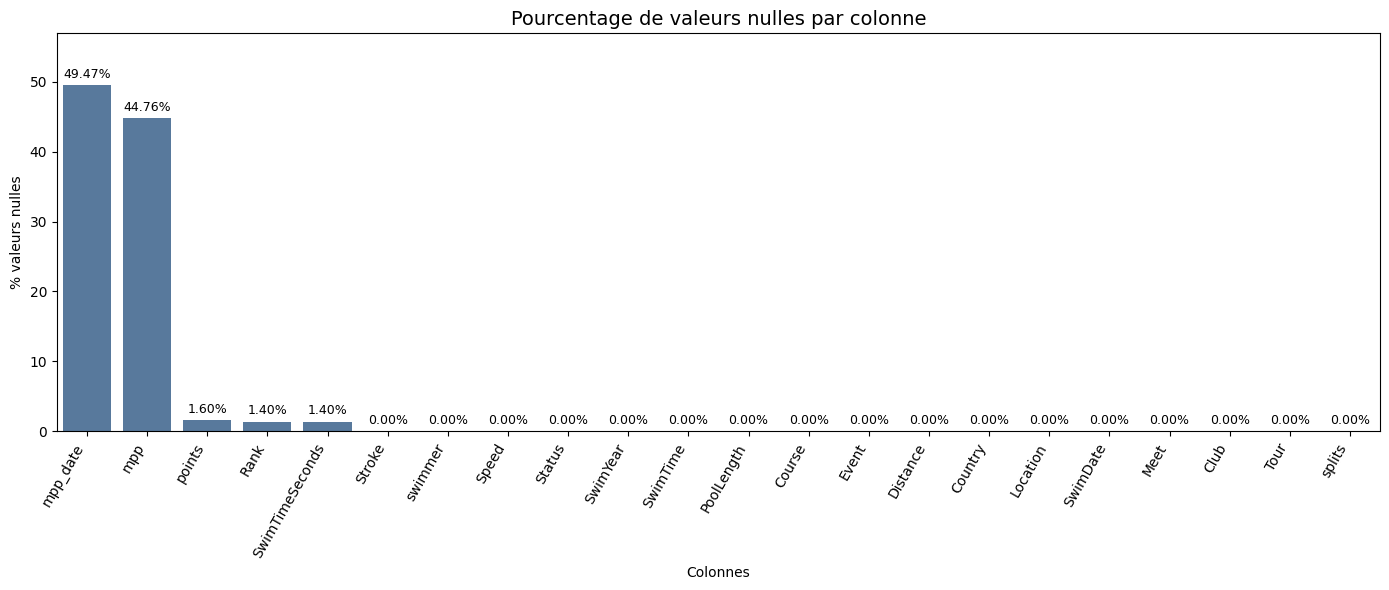

In [31]:
cols_to_check = [
    "Meet", "SwimDate", "Location", "Country", "Event", "Distance",
    "Stroke", "Course", "PoolLength", "Tour", "Rank", "Club", "points",
    "mpp", "mpp_date", "SwimTime", "SwimYear", "SwimTimeSeconds", "Status",
    "Speed", "swimmer", "splits"
]

missing_in_df = [c for c in cols_to_check if c not in df.columns]
if missing_in_df:
    print("Colonnes absentes dans df :", missing_in_df)

cols_present = [c for c in cols_to_check if c in df.columns]

n = len(df)
rows = []

for col in cols_present:
    s = df[col]
    null_mask = s.isna()
    empty_mask = s.map(lambda x: isinstance(x, str) and x.strip() == "")
    invalid_mask = null_mask | empty_mask

    nb_null = int(null_mask.sum())
    nb_empty = int(empty_mask.sum())
    nb_invalid = int(invalid_mask.sum())
    nb_valid = n - nb_invalid

    rows.append({
        "Column": col,
        "Total": n,
        "Null_count": nb_null,
        "Null_%": round((nb_null / n) * 100, 2) if n else 0,
        "Empty_string_count": nb_empty,
        "Empty_string_%": round((nb_empty / n) * 100, 2) if n else 0,
        "Null_or_empty_count": nb_invalid,
        "Null_or_empty_%": round((nb_invalid / n) * 100, 2) if n else 0,
        "Valid_count": nb_valid,
        "Valid_%": round((nb_valid / n) * 100, 2) if n else 0,
    })

quality_table = pd.DataFrame(rows).sort_values(
    by=["Null_or_empty_count", "Null_count", "Empty_string_count"],
    ascending=False
).reset_index(drop=True)

display(quality_table)

global_summary = pd.DataFrame([{
    "Total_rows": n,
    "Checked_columns": len(cols_present),
    "Columns_with_issues": int((quality_table["Null_or_empty_count"] > 0).sum()),
    "Columns_without_issues": int((quality_table["Null_or_empty_count"] == 0).sum()),
}])

display(global_summary)

plot_df = quality_table.copy().sort_values("Null_%", ascending=False)

plt.figure(figsize=(14, 6))
ax = sns.barplot(data=plot_df, x="Column", y="Null_%", color="#4C78A8")

plt.title("Pourcentage de valeurs nulles par colonne", fontsize=14)
plt.xlabel("Colonnes")
plt.ylabel("% valeurs nulles")
plt.xticks(rotation=60, ha="right")
plt.ylim(0, max(5, plot_df["Null_%"].max() * 1.15))

# Afficher la valeur sur chaque barre
for p in ax.patches:
    h = p.get_height()
    ax.annotate(f"{h:.2f}%",
                (p.get_x() + p.get_width() / 2, h),
                ha="center", va="bottom", fontsize=9, xytext=(0, 3),
                textcoords="offset points")

plt.tight_layout()
plt.show()

<h2 style="color:gray; font-size:20px;">SwimYear</h2>

In [32]:
from datetime import datetime
swimyear_num = pd.to_numeric(df["SwimYear"], errors="coerce")

annee_actuelle = datetime.now().year

mask_valide = swimyear_num.notna() & (swimyear_num <= annee_actuelle)

df_invalid = df.loc[~mask_valide, ["SwimDate", "SwimYear", "Meet", "Event"]].copy()

print(f"Total lignes               : {len(df)}")
print(f"SwimYear valides           : {mask_valide.sum()} ({mask_valide.mean()*100:.2f}%)")
print(f"SwimYear invalides / vides : {(~mask_valide).sum()} ({(~mask_valide).mean()*100:.2f}%)")

nb_vides = swimyear_num.isna().sum()
nb_futures = (swimyear_num > annee_actuelle).sum()

print(f"- SwimYear vides/non numériques : {nb_vides}")
print(f"- SwimYear > année actuelle     : {nb_futures}")

display(df_invalid.head(20))

Total lignes               : 759459
SwimYear valides           : 759459 (100.00%)
SwimYear invalides / vides : 0 (0.00%)
- SwimYear vides/non numériques : 0
- SwimYear > année actuelle     : 0


,SwimDate,SwimYear,Meet,Event


<h2 style="color:gray; font-size:20px;">Year_of_birth</h2>

In [33]:
df_check = df.explode("swimmer").copy()
df_check = df_check[df_check["swimmer"].apply(lambda x: isinstance(x, dict))]

current_year = pd.Timestamp.today().year
year_of_birth_num = pd.to_numeric(
    df_check["swimmer"].apply(lambda x: x.get("Year_of_birth")),
    errors="coerce"
)

valid_mask = year_of_birth_num.notna() & (year_of_birth_num <= current_year)
invalid_or_future_mask = year_of_birth_num.isna() | (year_of_birth_num > current_year)

total = len(df_check)
nb_valid = int(valid_mask.sum())
nb_invalid_or_future = int(invalid_or_future_mask.sum())

pct_valid = (nb_valid / total * 100) if total else 0
pct_invalid_or_future = (nb_invalid_or_future / total * 100) if total else 0

print(f"Total lignes                                        : {total}")
print(f"Year_of_birth valides                               : {nb_valid} ({pct_valid:.5f}%)")
print(f"Year_of_birth non valides ou superieure a la date actuelle : {nb_invalid_or_future} ({pct_invalid_or_future:.5f}%)")

Total lignes                                        : 887780
Year_of_birth valides                               : 887780 (100.00000%)
Year_of_birth non valides ou superieure a la date actuelle : 0 (0.00000%)


<h2 style="color:gray; font-size:20px;">Stroke</h2>

In [34]:
print(df['Stroke'].unique()) 

['FR' 'BK' 'BR' 'FL' 'MD']


<h2 style="color:gray; font-size:20px;">Distance</h2>

In [35]:
print(df["Distance"].sort_values(ascending=True).unique()) 

[  25   50  100  200  400  500  800 1000 1200 1500]


<h2 style="color:gray; font-size:20px;">Event</h2>

In [38]:
print("Les event disponibles sont :")
print(df["Event"].unique()) 
print("Le nombre de event disponibles :",len(df["Event"].unique()))

Les event disponibles sont :
['200 FR SCM' '400 FR SCM' '50 BK SCM' '200 BK SCM' '50 BR SCM'
 '200 BR SCM' '50 FL SCM' '200 FL SCM' '200 MD SCM' '400 MD SCM'
 '500 FR SCM' '1000 FR SCM' '100 FR SCM' '100 BK SCM' '100 BR SCM'
 '100 FL SCM' '800 FR SCM' '50 FR SCM' '1500 FR SCM' '100 MD SCM'
 '50 FR LCM' '100 FR LCM' '200 FR LCM' '400 FR LCM' '800 FR LCM'
 '50 BK LCM' '100 BK LCM' '200 BK LCM' '50 BR LCM' '100 BR LCM'
 '200 BR LCM' '50 FL LCM' '100 FL LCM' '200 FL LCM' '200 MD LCM'
 '400 MD LCM' '1500 FR LCM' '25 BR SCM' '25 FR SCM' '25 BK SCM'
 '25 FL SCM' '1200 FR LCM' '500 FR LCM' '1000 FR LCM']
Le nombre de event disponibles : 44


<h2 style="color:gray; font-size:20px;">SwimTimeSeconds</h2>

In [65]:
total_lignes = len(df)

nb_null = df['SwimTimeSeconds'].isna().sum()
pourcentage_null = (nb_null / total_lignes) * 100

nb_empty = (df['SwimTimeSeconds'] == "").sum()
pourcentage_empty = (nb_empty / total_lignes) * 100

print(f"Nombre de SwimTimeSeconds nulles (NaN) : {nb_null} ({pourcentage_null:.2f}%)")
print(f"Nombre de SwimTimeSeconds vides ('') : {nb_empty} ({pourcentage_empty:.2f}%)")

Nombre de SwimTimeSeconds nulles (NaN) : 10596 (1.40%)
Nombre de SwimTimeSeconds vides ('') : 0 (0.00%)


In [ ]:
def get_split_seconds_list(splits):
    vals = []
    if not (isinstance(splits, list) and len(splits) > 0):
        return vals
    for s in splits:
        if not isinstance(s, dict):
            continue
        v = s.get("split_seconds")
        if v is None:
            continue
        try:
            vals.append(float(v))
        except Exception:
            continue
    return vals

split_secs_per_perf = df["splits"].apply(get_split_seconds_list)

mask_with_splits = split_secs_per_perf.apply(lambda L: len(L) > 0)
nb_perf_with_splits = int(mask_with_splits.sum())

mask_perf_lt_20 = split_secs_per_perf.apply(lambda L: len(L) > 0 and any(x < 20 for x in L))
mask_perf_gt_120 = split_secs_per_perf.apply(lambda L: len(L) > 0 and any(x > 120 for x in L))
mask_perf_both = split_secs_per_perf.apply(lambda L: len(L) > 0 and any(x < 20 for x in L) and any(x > 120 for x in L))

nb_perf_lt_20 = int(mask_perf_lt_20.sum())
nb_perf_gt_120 = int(mask_perf_gt_120.sum())
nb_perf_both = int(mask_perf_both.sum())

pct_perf_with_splits = (nb_perf_with_splits / len(df) * 100) if len(df) else 0

# % des cas <20, >120, both parmi les performances exploitables
pct_perf_lt_20 = (nb_perf_lt_20 / nb_perf_with_splits * 100) if nb_perf_with_splits else 0
pct_perf_gt_120 = (nb_perf_gt_120 / nb_perf_with_splits * 100) if nb_perf_with_splits else 0
pct_perf_both = (nb_perf_both / nb_perf_with_splits * 100) if nb_perf_with_splits else 0

print(f"Performances totales                  : {len(df)}")
print(f"Performances avec splits exploitables : {nb_perf_with_splits} ({pct_perf_with_splits:.2f}%)")
print(f"Perf avec >=1 split_seconds < 20 sec  : {nb_perf_lt_20} ({pct_perf_lt_20:.2f}%)")
print(f"Perf avec >=1 split_seconds > 120 sec : {nb_perf_gt_120} ({pct_perf_gt_120:.2f}%)")
print(f"Perf avec les deux conditions         : {nb_perf_both} ({pct_perf_both:.2f}%)")

Performances totales                  : 759459
Performances avec splits exploitables : 499961 (65.83%)
Perf avec >=1 split_seconds < 20 sec  : 0 (0.00%)
Perf avec >=1 split_seconds > 120 sec : 0 (0.00%)
Perf avec les deux conditions         : 0 (0.00%)


<h2 style="color:gray; font-size:20px;">Swimmer</h2>

In [51]:
df['swimmer_name'] = df['swimmer'].apply(
    lambda x: x[0]['Name'] if isinstance(x, list) and len(x) > 0 else None
)

participations = df.groupby(['swimmer_name', 'Event']).size().reset_index(name='count')

max_count = participations['count'].max()

max_participations = participations[participations['count'] == max_count]

print("Le nageur ayant le nombre de performances le plus élevé est :")
print(max_participations[['swimmer_name', 'Event', 'count']])

Le nageur ayant le nombre de performances le plus élevé est :
           swimmer_name      Event  count
128652  Henique Mélanie  50 FL LCM    144


In [ ]:
nom_event = "400 MD LCM"

df['swimmer_name'] = df['swimmer'].apply(
    lambda x: x[0]['Name'] if isinstance(x, list) and len(x) > 0 else None
)

df_filtered = df[df['swimmer_name'].notna()]

total_participations = (
    df_filtered[df_filtered['Event'] == nom_event]
    .groupby('swimmer_name')
    .size()
    .reset_index(name='total_participations')
)

valid_performances = (
    df_filtered[(df_filtered['Event'] == nom_event) & df_filtered['SwimTimeSeconds'].notna()]
    .groupby('swimmer_name')
    .size()
    .reset_index(name='valid_performances')
)

top_swimmers = pd.merge(total_participations, valid_performances, on='swimmer_name', how='left')

top_swimmers = top_swimmers.sort_values(by='total_participations', ascending=False).head(10)

top_swimmers['valid_performances'] = top_swimmers['valid_performances'].fillna(0).astype(int)
top_swimmers['total_participations'] = top_swimmers['total_participations'].astype(int)

top_swimmers = top_swimmers.rename(columns={
    'swimmer_name': 'Nom des nageurs',
    'total_participations': 'Total performances',
    'valid_performances': 'Total performances valides'
})

print("Les nageurs qui ont le nombre de performances le plus élevé pour le event", nom_event, " :")
print(top_swimmers)

Les nageurs qui ont le nombre de performances le plus élevé pour le event 400 MD LCM  :
               Nom des nageurs  Total performances  Total performances valides
6338           Renard Geoffrey                  72                          72
4479          Lesaffre Fantine                  69                          67
3110  Grangeon-De Villele Lara                  66                          65
7662           Verraszto David                  66                          66
4982          Mattenet Emilien                  66                          66
3526            Hosszu Katinka                  58                          58
7340         Tissandie Camille                  57                          57
7169              Syoud Jaouad                  54                          54
2304          Duhamel Cyrielle                  53                          53
3166                Gruart Leo                  53                          53


<h2 style="color:gray; font-size:20px;">Split</h2>

In [103]:
df_check = df[["Meet", "Event", "Distance", "splits"]].copy()
df_check["Distance_num"] = pd.to_numeric(df_check["Distance"], errors="coerce")

mask_has_splits = df_check["splits"].apply(lambda x: isinstance(x, list) and len(x) > 0)
df_with_splits = df_check[mask_has_splits & df_check["Distance_num"].notna()].copy()

def get_last_split_distance(splits):
    last = splits[-1]
    if not isinstance(last, dict):
        return None
    raw = last.get("split_distance")
    if raw is None:
        return None
    try:
        return float(str(raw).replace("m", "").strip())
    except Exception:
        return None

df_with_splits["LastSplitDistance"] = df_with_splits["splits"].apply(get_last_split_distance)

tol = 1e-9
mask_valid_last = df_with_splits["LastSplitDistance"].notna()
mask_inferieur = mask_valid_last & (df_with_splits["LastSplitDistance"] < df_with_splits["Distance_num"])
mask_egal = mask_valid_last & ((df_with_splits["LastSplitDistance"] - df_with_splits["Distance_num"]).abs() <= tol)

nb_total_with_splits = len(df_with_splits)
nb_last_valid = int(mask_valid_last.sum())

nb_inferieur = int(mask_inferieur.sum())
pct_inferieur = (nb_inferieur / nb_total_with_splits * 100) if nb_total_with_splits else 0

nb_egal = int(mask_egal.sum())
pct_egal = (nb_egal / nb_total_with_splits * 100) if nb_total_with_splits else 0

print(f"Performances avec splits (Distance valide) : {nb_total_with_splits}")
print(f"Performances avec dernier split exploitable: {nb_last_valid}")
print(f"Dernier split < Distance                   : {nb_inferieur} ({pct_inferieur:.2f}%)")
print(f"Dernier split = Distance                   : {nb_egal} ({pct_egal:.2f}%)")

top_meets_problem = (
    df_with_splits.loc[mask_inferieur, "Meet"]
    .dropna()
    .astype(str)
    .value_counts()
    .head(5)
)

print("\nTop 5 meets où dernier split < Distance :")
for meet, n in top_meets_problem.items():
    print(f"- {meet} : {n} performances")

top_meet_event_problem = (
    df_with_splits.loc[mask_inferieur, ["Meet", "Event"]]
    .dropna(subset=["Meet", "Event"])
    .astype(str)
    .value_counts()
    .reset_index(name="nb_performances")
    .head(5)
)

print("\nTop 5 couples (Meet, Event) où dernier split < Distance :")
for _, row in top_meet_event_problem.iterrows():
    print(f"- {row['Meet']} | {row['Event']} : {row['nb_performances']} performances")

Performances avec splits (Distance valide) : 499961
Performances avec dernier split exploitable: 499961
Dernier split < Distance                   : 25363 (5.07%)
Dernier split = Distance                   : 474598 (94.93%)

Top 5 meets où dernier split < Distance :
- Championnats du Monde en grand bassin : 2137 performances
- Championnats de France Elite : 1880 performances
- Championnats de France en petit bassin : 1615 performances
- Championnats d'Europe Juniors : 1437 performances
- Championnats d'Europe en grand bassin : 1278 performances

Top 5 couples (Meet, Event) où dernier split < Distance :
- Championnats du Monde en grand bassin | 800 FR LCM : 1388 performances
- Championnats de France Elite | 800 FR LCM : 1053 performances
- Championnats d'Europe Juniors | 800 FR LCM : 965 performances
- Championnats de France en petit bassin | 800 FR SCM : 935 performances
- Championnats de France Elite | 1500 FR LCM : 827 performances


In [127]:
nb_total = len(df)

def has_nonempty_splits(x):
    return isinstance(x, list) and len(x) > 0

mask_splits = df["splits"].apply(has_nonempty_splits)
nb_avec_splits = int(mask_splits.sum())
pct_avec_splits_total = (nb_avec_splits / nb_total * 100) if nb_total else 0

df_s = df.loc[mask_splits]

def swimmer_len(x):
    if isinstance(x, list):
        return len(x)
    return None  

df_s = df_s.copy()
df_s["_swimmer_len"] = df_s["swimmer"].apply(swimmer_len)

mask_1_swimmer = df_s["_swimmer_len"] == 1
mask_plusieurs_swimmers = df_s["_swimmer_len"].notna() & (df_s["_swimmer_len"] > 1)
mask_swimmer_invalide = df_s["_swimmer_len"].isna() | (df_s["_swimmer_len"] == 0)

nb_1_swimmer = int(mask_1_swimmer.sum())
nb_plusieurs = int(mask_plusieurs_swimmers.sum())
nb_swimmer_bizarre = int(mask_swimmer_invalide.sum())

pct_1_swimmer_total = (nb_1_swimmer / nb_total * 100) if nb_total else 0
pct_plusieurs_total = (nb_plusieurs / nb_total * 100) if nb_total else 0

base = nb_avec_splits
pct_1_swimmer_sur_splits = (nb_1_swimmer / base * 100) if base else 0
pct_plusieurs_sur_splits = (nb_plusieurs / base * 100) if base else 0
pct_bizarre_sur_splits = (nb_swimmer_bizarre / base * 100) if base else 0

print(f"Total performances                              : {nb_total}")
print(f"Avec au moins 1 split                           : {nb_avec_splits} ({pct_avec_splits_total:.2f}% du total)")
print()
print("Parmi les performances avec splits :")
print(f"  - swimmer liste de longueur 1                 : {nb_1_swimmer} ({pct_1_swimmer_sur_splits:.2f}% des perfs avec splits)")
print(f"  - swimmer liste longueur > 1                  : {nb_plusieurs} ({pct_plusieurs_sur_splits:.2f}% des perfs avec splits)")
print(f"  - swimmer absent / pas liste / liste vide     : {nb_swimmer_bizarre} ({pct_bizarre_sur_splits:.2f}% des perfs avec splits)")
print()
print("Pour comparaison (par rapport au total toutes perfs) :")
print(f"  - avec splits + exactement 1 swimmer                     : {nb_1_swimmer} ({pct_1_swimmer_total:.2f}% du total)")
print(f"  - avec splits + plusieurs swimmers (en relais)           : {nb_plusieurs} ({pct_plusieurs_total:.2f}% du total)")

Total performances                              : 759459
Avec au moins 1 split                           : 499961 (65.83% du total)

Parmi les performances avec splits :
  - swimmer liste de longueur 1                 : 466134 (93.23% des perfs avec splits)
  - swimmer liste longueur > 1                  : 33827 (6.77% des perfs avec splits)
  - swimmer absent / pas liste / liste vide     : 0 (0.00% des perfs avec splits)

Pour comparaison (par rapport au total toutes perfs) :
  - avec splits + exactement 1 swimmer                     : 466134 (61.38% du total)
  - avec splits + plusieurs swimmers (en relais)           : 33827 (4.45% du total)


<h1 style="color:rgb(242, 176, 235); font-size:32px;">Distributions de temps</h1>

<h2 style="color:gray; font-size:20px;">Histogram of swim times</h2>

Nombre de performances pour l'event 100 FR LCM: 49722


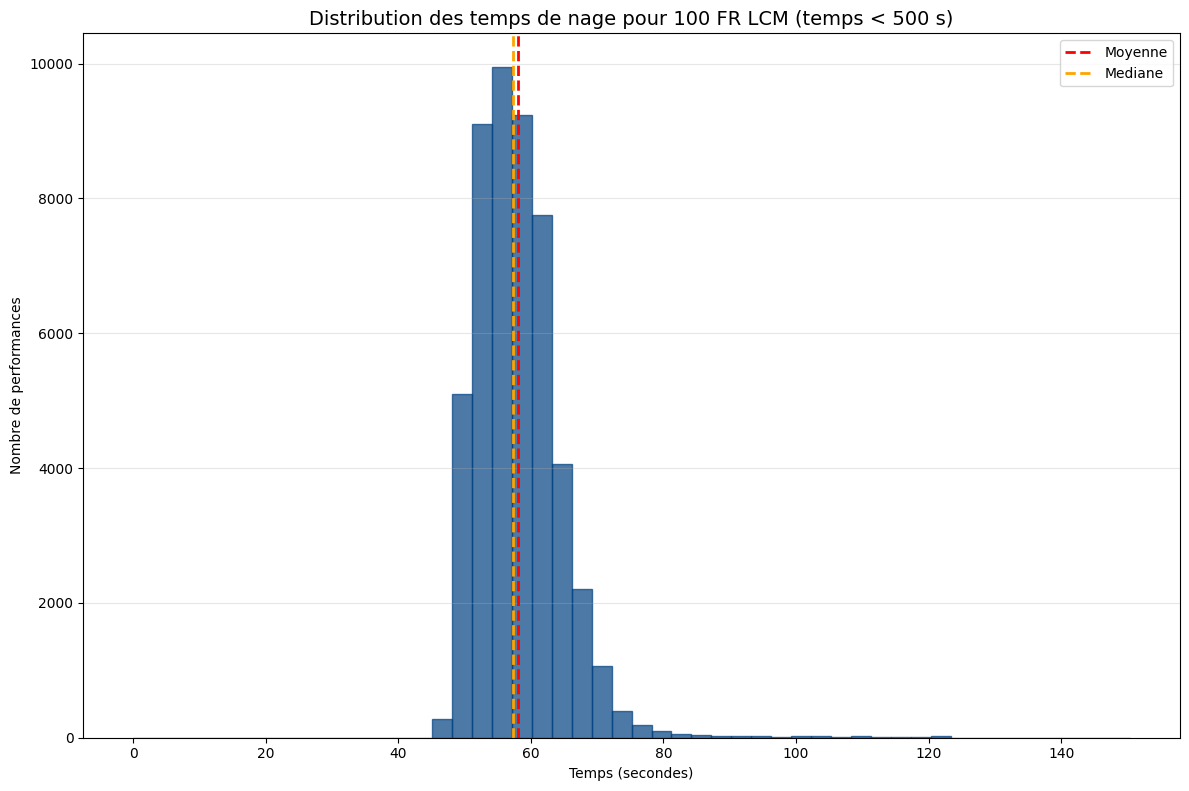

In [4]:
nom_event = "100 FR LCM"

df_event = df.loc[df["Event"] == nom_event].copy()
nb_perf = pd.to_numeric(df_event["SwimTimeSeconds"], errors="coerce").lt(500).sum()
print(f"Nombre de performances pour l'event {nom_event}: {nb_perf}")

service = ServiceGraphe()
fig = service.build_figure(Graphe1, df_event)

# Personnalisation du titre pour cet event.
ax = fig.axes[0]
ax.set_title(f"Distribution des temps de nage pour {nom_event} (temps < 500 s)", fontsize=14)

plt.show()

<h2 style="color:gray; font-size:20px;">Histogram with Kernel Density Estimate (KDE)</h2>

Nombre de performances pour l'event 400 MD LCM: 25187


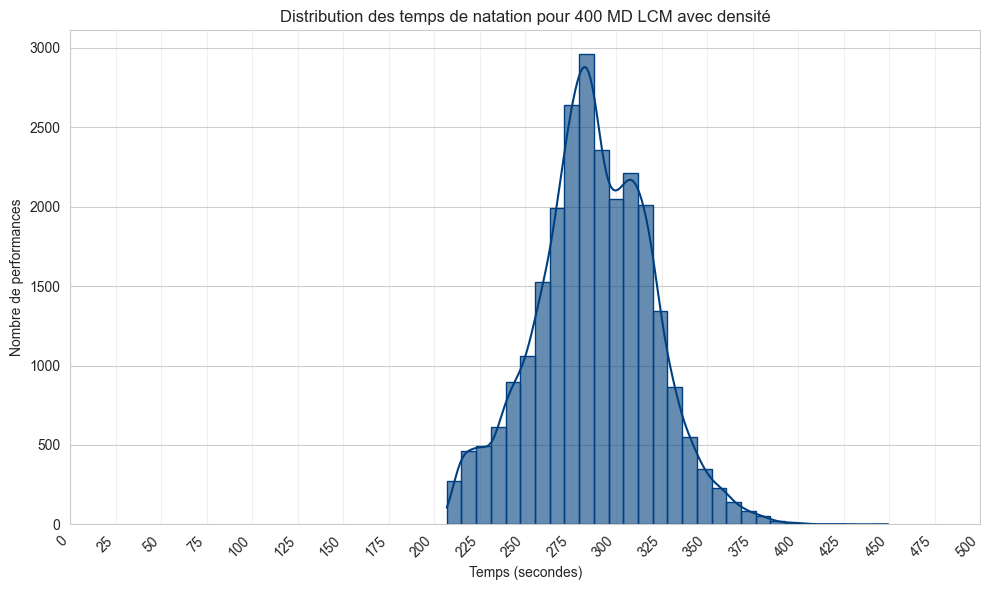

In [ ]:
import importlib
import services.graph_service as graph_service

# Recharge le module pour prendre les dernières méthodes ajoutées.
importlib.reload(graph_service)
service = graph_service.ServiceGraphe()

nom_event = "400 MD LCM"

df_event = df.loc[df["Event"] == nom_event].copy()
nb_perf = pd.to_numeric(df_event["SwimTimeSeconds"], errors="coerce").lt(500).sum()
print(f"Nombre de performances pour l'event {nom_event}: {nb_perf}")

fig = service.build_figure(graph_service.Graphe6, df_event)

ax = fig.axes[0]
ax.set_title(f"Distribution des temps de natation pour {nom_event} avec densité")

plt.show()

<h2 style="color:gray; font-size:20px;">Cumulative Histogram</h2>

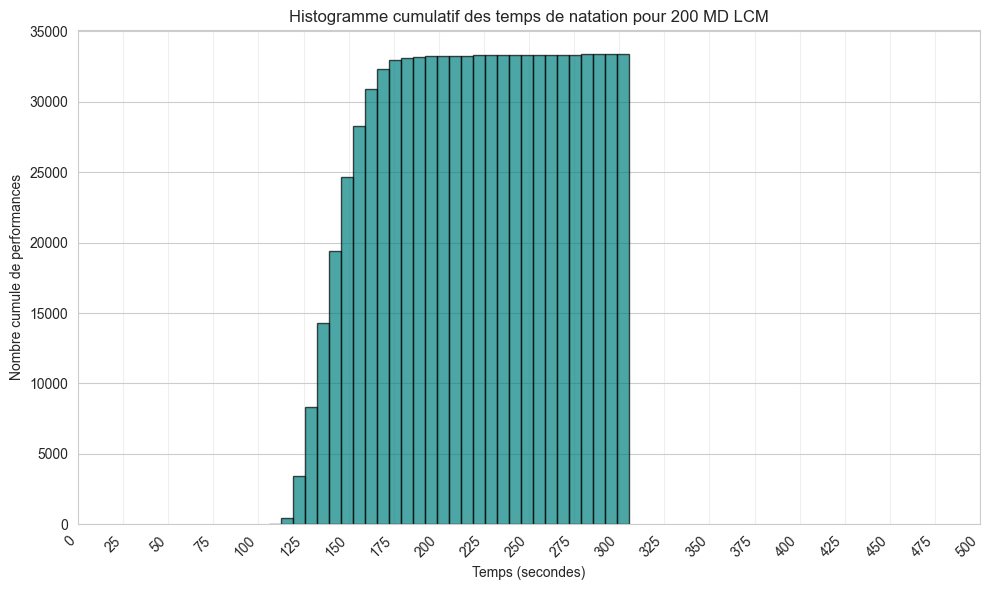

In [37]:
import importlib
import services.graph_service as graph_service

# Recharge le module pour prendre les dernières méthodes ajoutées.
importlib.reload(graph_service)
service = graph_service.ServiceGraphe()

nom_event = "200 MD LCM"

df_event = df.loc[df["Event"] == nom_event].copy()
nb_perf = pd.to_numeric(df_event["SwimTimeSeconds"], errors="coerce").lt(500).sum()

if nb_perf > 0:
    # Architecture durable: appel via GraphSpec (Graphe7 = histogramme cumulatif).
    fig = service.build_figure(graph_service.Graphe7, df_event)

    # Personnalisation du titre pour cet event.
    ax = fig.axes[0]
    ax.set_title(f"Histogramme cumulatif des temps de natation pour {nom_event}")

    plt.show()
else:
    print(f"Aucune donnée disponible pour l'événement {nom_event}")

<h1 style="color:rgb(242, 176, 235); font-size:32px;">Effectifs et répartition par sexe</h1>

<h2 style="color:gray; font-size:20px;">Bar Chart of Total Performances by Event and Gender</h2>

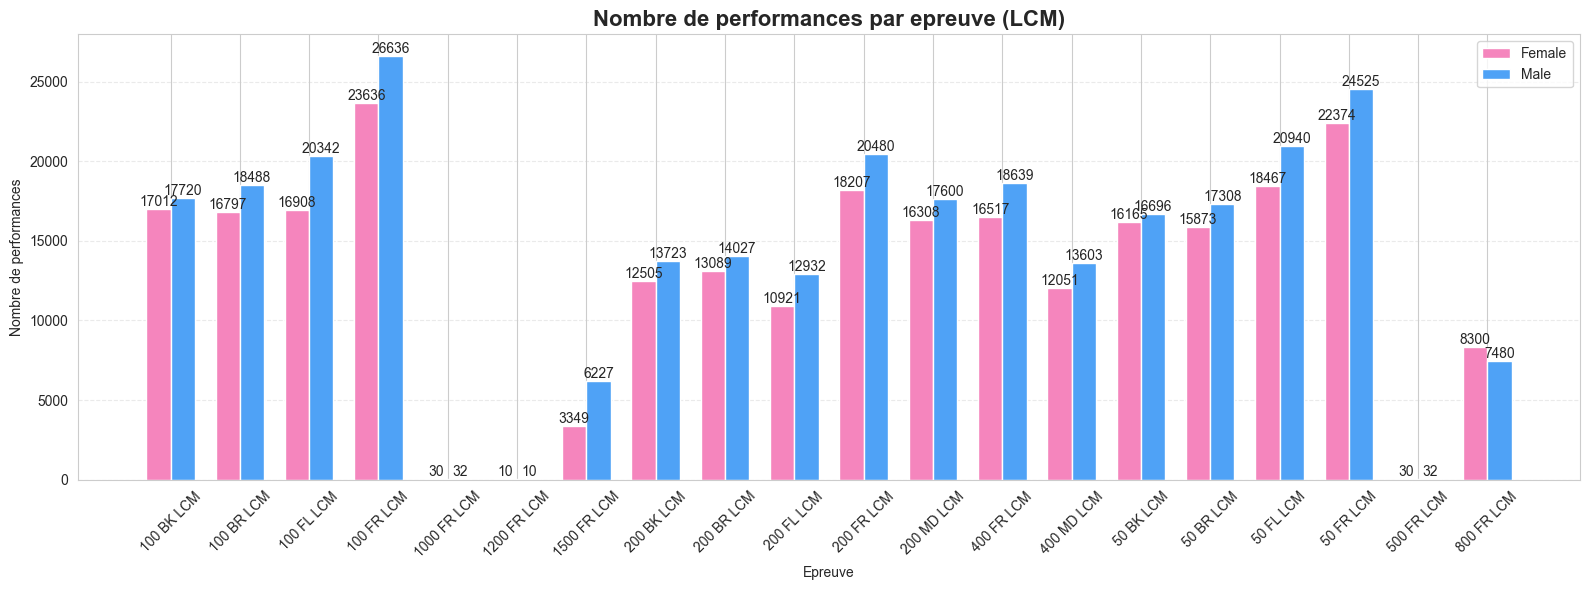

In [38]:
import importlib
import services.graph_service as graph_service

# Recharge le module pour prendre les dernières méthodes ajoutées.
importlib.reload(graph_service)
service = graph_service.ServiceGraphe()

course_type = "LCM"

fig = service.build_figure(graph_service.Graphe8, df)
plt.show()

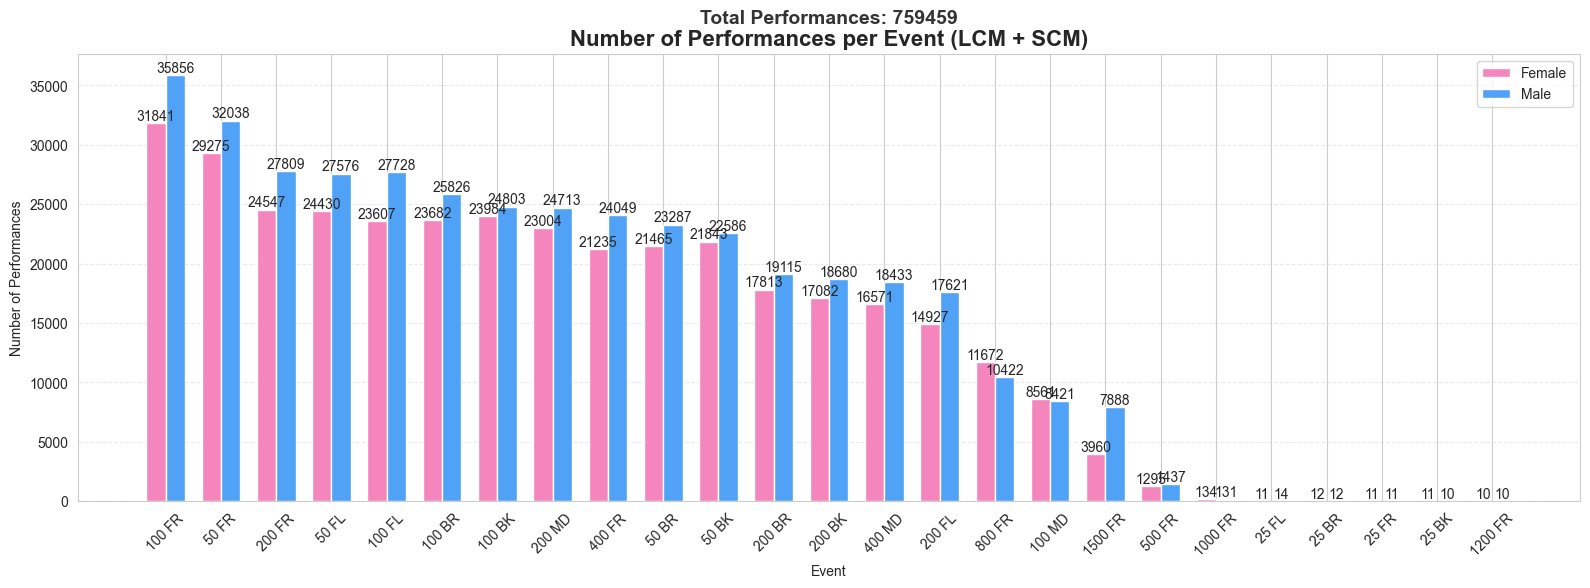

In [39]:
import importlib
import services.graph_service as graph_service

# Recharge le module pour prendre les dernières méthodes ajoutées.
importlib.reload(graph_service)
service = graph_service.ServiceGraphe()

fig = service.build_figure(graph_service.Graphe9, df)
plt.show()


<h2 style="color:gray; font-size:20px;">Countplot total number of performances by sex</h2>

/Users/nouhailaimaneabbassi/Desktop/Pacing/services/graph_service.py:463: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  )


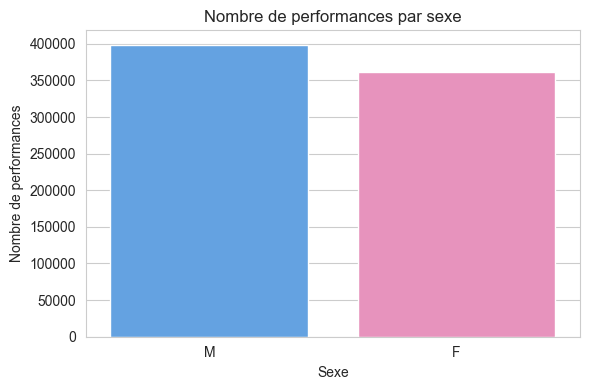

In [49]:
# Architecture durable: appel via GraphSpec (Graphe10 = nombre de performances par sexe).
fig = service.build_figure(graph_service.Graphe10, df)
plt.show()

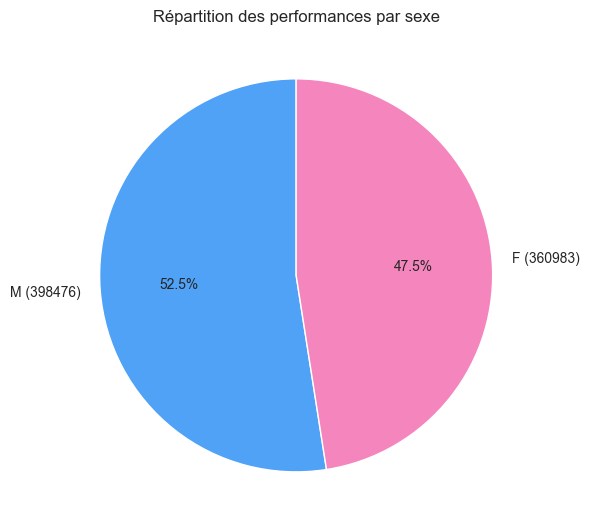

In [58]:
# Architecture durable: appel via GraphSpec (Graphe2 = camembert sexe global).
fig = service.build_figure(graph_service.Graphe2, df)

# Personnalisation optionnelle du titre dans le notebook.
ax = fig.axes[0]
ax.set_title("Répartition des performances par sexe")

plt.show()

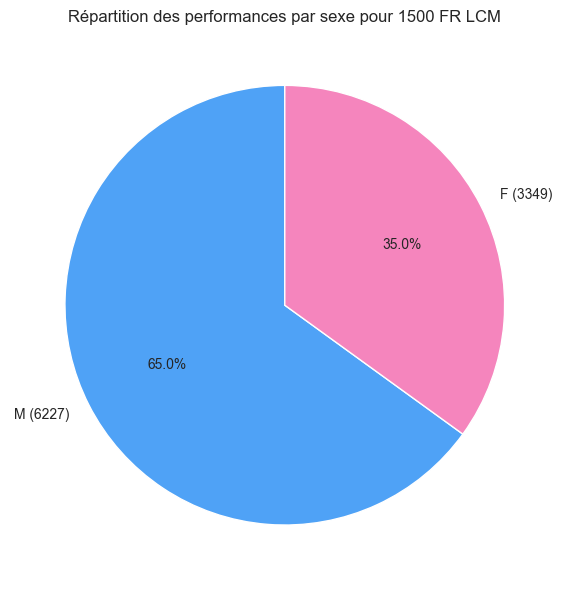

In [60]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("/Users/nouhailaimaneabbassi/Desktop/Pacing")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import importlib
import services.graph_service as graph_service
import matplotlib.pyplot as plt

# Recharge le module pour prendre les dernières méthodes ajoutées.
importlib.reload(graph_service)
service = graph_service.ServiceGraphe()

nom_event = "1500 FR LCM"
fig = service.build_figure(graph_service.Graphe14, df, nom_event=nom_event)

if fig is not None:
    plt.show()
else:
    print(f"Aucune donnée disponible pour l'événement {nom_event}")

<h1 style="color:rgb(242, 176, 235); font-size:32px;">Distribution des temps par nage</h1>

<h2 style="color:gray; font-size:20px;">Boxplot (Boite à moustaches) du temps par stroke et la distance</h2>

/Users/nouhailaimaneabbassi/Desktop/Pacing/services/graph_service.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax.set_ylabel("Nombre de participations")


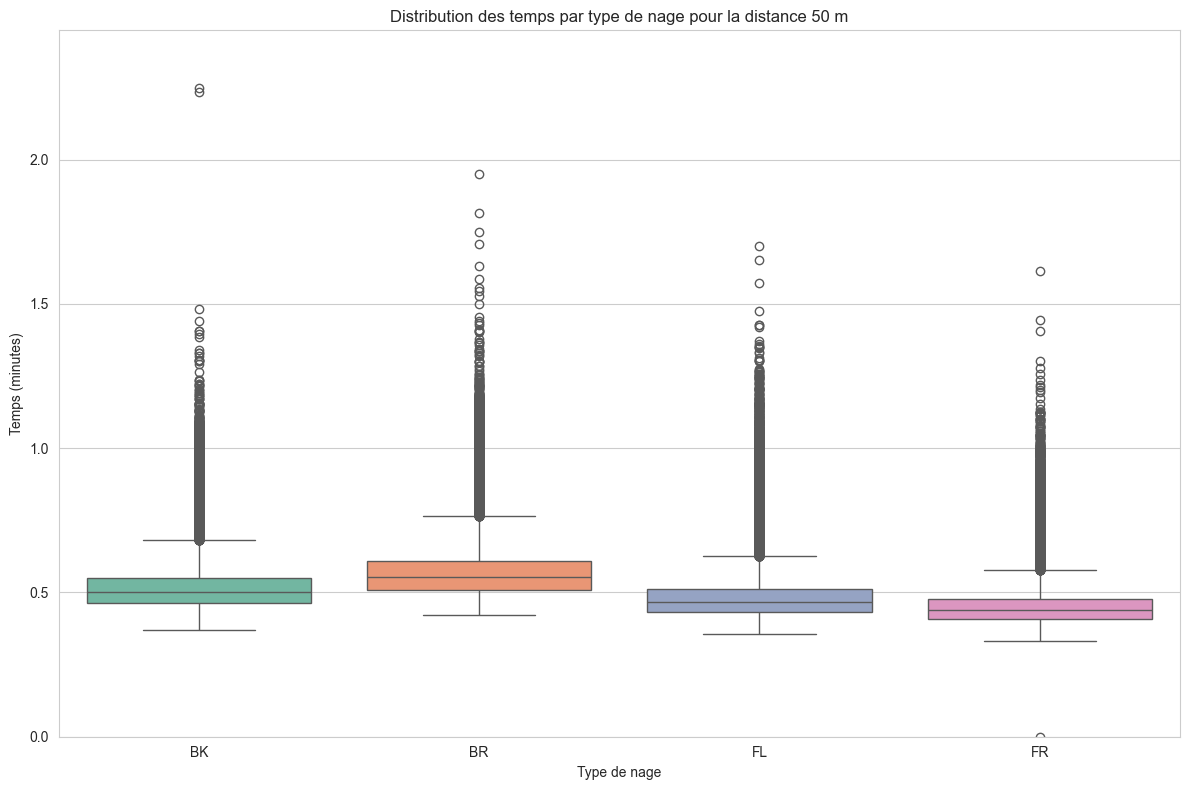

In [62]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("/Users/nouhailaimaneabbassi/Desktop/Pacing")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import importlib
import services.graph_service as graph_service
import matplotlib.pyplot as plt

# Recharge le module pour prendre les dernières méthodes ajoutées.
importlib.reload(graph_service)
service = graph_service.ServiceGraphe()

distance_choisie = 50

subset = df[
    (df["SwimTimeSeconds"].notna()) &
    (df["Distance"] == distance_choisie)
].copy()

if len(subset) > 0:
    fig = service.build_figure(graph_service.Graphe3, subset)

    # Personnalisation spécifique à cette distance
    ax = fig.axes[0]
    ax.set_title(f"Distribution des temps par type de nage pour la distance {distance_choisie} m")
    ax.set_ylim(0, (subset["SwimTimeSeconds"] / 60).max() + 0.2)

    plt.show()
else:
    print(f"Aucune donnée disponible pour la distance {distance_choisie} m")

<h1 style="color:rgb(242, 176, 235); font-size:32px;">Clubs</h1>

<h2 style="color:gray; font-size:20px;">Bar Chart of Number of Performances per Club</h2>

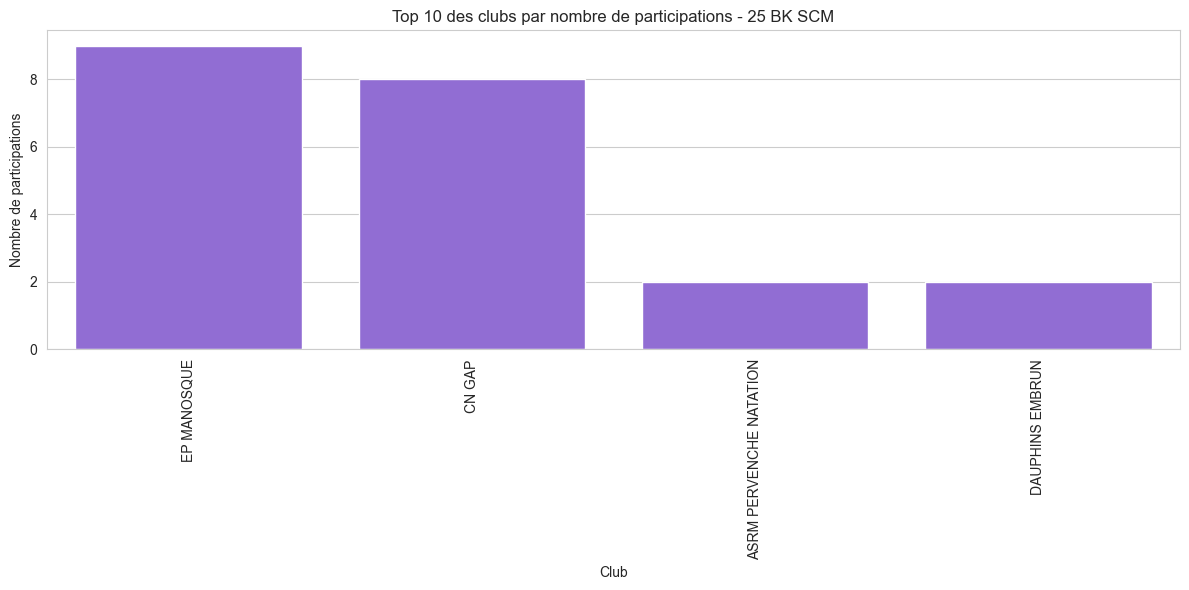

In [64]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("/Users/nouhailaimaneabbassi/Desktop/Pacing")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import importlib
import services.graph_service as graph_service
import matplotlib.pyplot as plt

# Recharge le module pour prendre les dernières méthodes ajoutées.
importlib.reload(graph_service)
service = graph_service.ServiceGraphe()

nom_event = "25 BK SCM"
df_event = df[df["Event"] == nom_event].copy()

if len(df_event) > 0:
    fig = service.build_figure(graph_service.Graphe4, df_event)

    # Personnalisation pour l'event ciblé
    ax = fig.axes[0]
    ax.set_title(f"Top 10 des clubs par nombre de participations - {nom_event}")

    plt.show()
else:
    print(f"Aucune donnée disponible pour l'événement {nom_event}")

In [7]:
nom_event = "25 BK SCM"

clubs = (
    df[df["Event"] == nom_event]["Club"]
    .dropna()
    .unique()
)

print("Clubs participants :")
print(clubs)

Clubs participants :
['ASRM PERVENCHE NATATION' 'CN GAP' 'EP MANOSQUE' 'DAUPHINS EMBRUN']


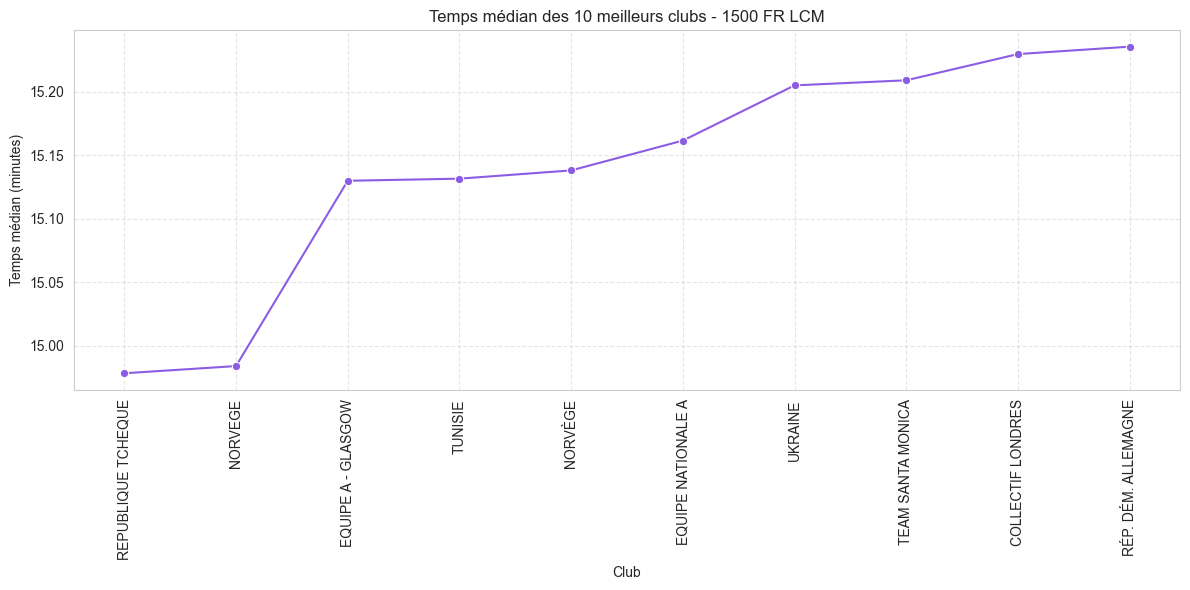

,Club,SwimTimeMinutes
500,REPUBLIQUE TCHEQUE,14.978167
459,NORVEGE,14.983833
285,EQUIPE A - GLASGOW,15.129833
602,TUNISIE,15.131500
460,NORVÈGE,15.138000
288,EQUIPE NATIONALE A,15.161500
605,UKRAINE,15.205000
591,TEAM SANTA MONICA,15.209000
233,COLLECTIF LONDRES,15.229667
506,RÉP. DÉM. ALLEMAGNE,15.235500


In [65]:
import sys
from pathlib import Path
import importlib
import services.graph_service as graph_service

PROJECT_ROOT = Path("/Users/nouhailaimaneabbassi/Desktop/Pacing")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

importlib.reload(graph_service)
service = graph_service.ServiceGraphe()

nom_event = "1500 FR LCM"
fig, top10_clubs = service.build_figure(graph_service.Graphe11, df, nom_event=nom_event)

if fig is not None:
    plt.show()
    display(top10_clubs)
else:
    print(f"Aucune donnée disponible pour l'événement {nom_event}")

<h1 style="color:rgb(242, 176, 235); font-size:32px;">Chronos dans le temps</h1>

<h2 style="color:gray; font-size:20px;">Line Plot of Swim Times by Stroke Type Over Time for a Sample of 5000</h2>

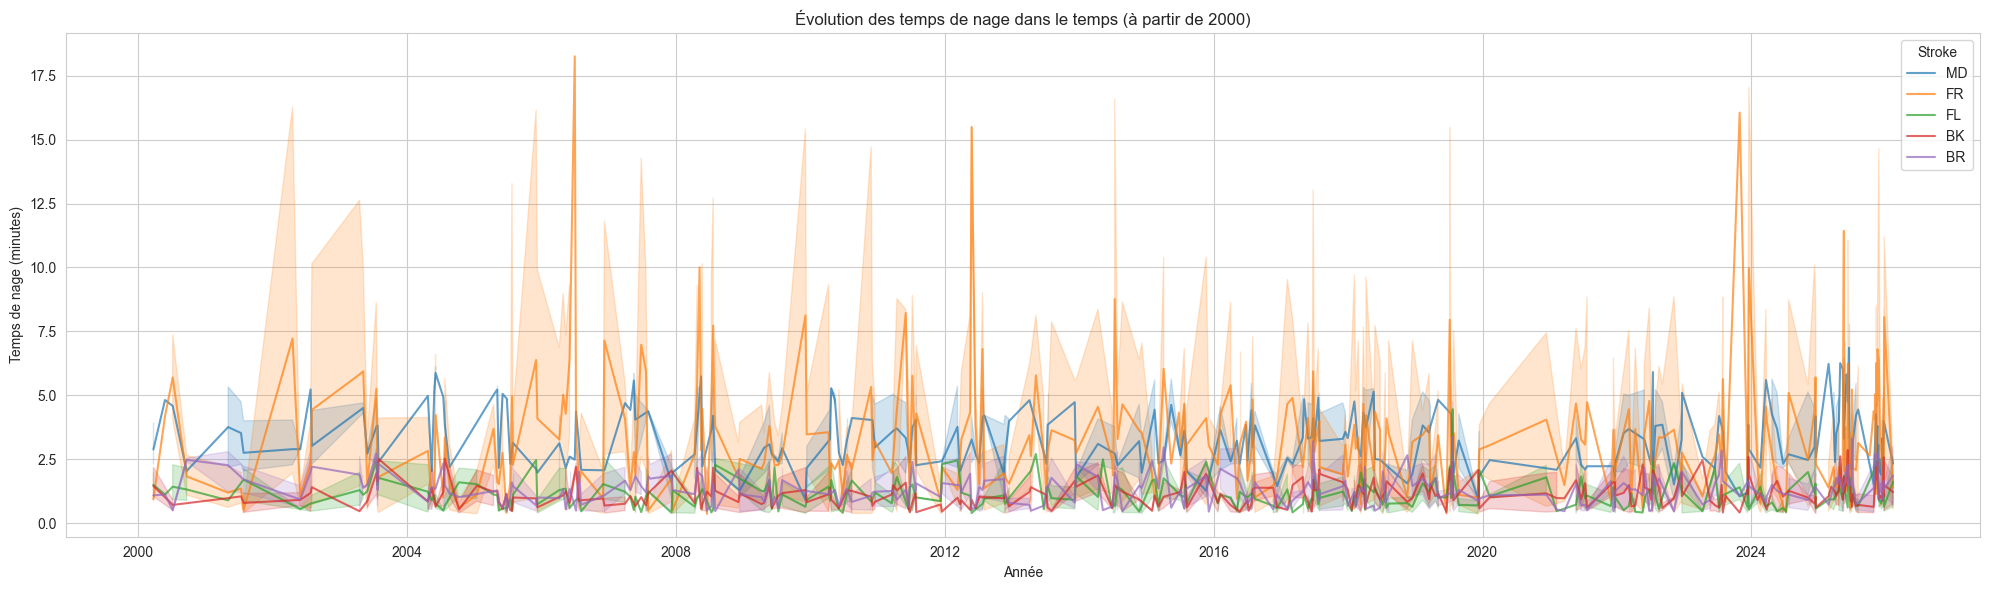

In [70]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("/Users/nouhailaimaneabbassi/Desktop/Pacing")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import importlib
import services.graph_service as graph_service
import matplotlib.pyplot as plt

# Recharge le module pour prendre les dernières méthodes ajoutées.
importlib.reload(graph_service)
service = graph_service.ServiceGraphe()

fig = service.build_figure(graph_service.Graphe12, df, start_year=2000, sample_size=5000)
if fig is not None:
    plt.show()
else:
    print("Aucune donnée disponible pour tracer l'évolution des temps.")

In [71]:
df['SwimDate'] = pd.to_datetime(df['SwimDate'], errors='coerce')

df['Year'] = df['SwimDate'].dt.year

min_year = df['Year'].min()

print("L'année la plus ancienne est :", min_year)

L'année la plus ancienne est : 1976


/Users/nouhailaimaneabbassi/Desktop/Pacing/services/graph_service.py:605: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



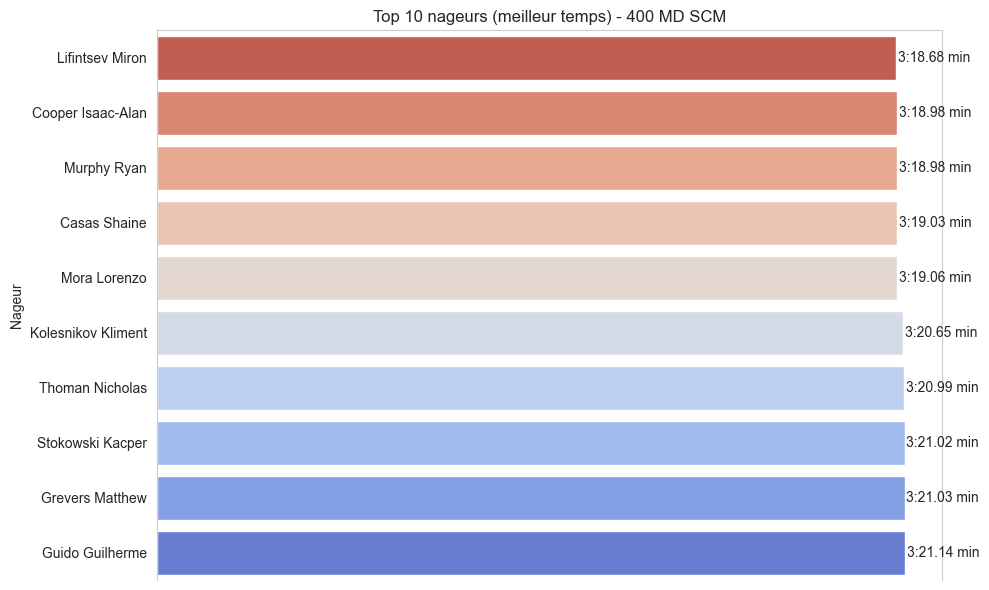

,SwimmerName,SwimTimeSeconds
3143,Lifintsev Miron,198.68
1181,Cooper Isaac-Alan,198.98
3712,Murphy Ryan,198.98
931,Casas Shaine,199.03
3620,Mora Lorenzo,199.06
2760,Kolesnikov Kliment,200.65
4877,Thoman Nicholas,200.99
4752,Stokowski Kacper,201.02
2239,Grevers Matthew,201.03
2285,Guido Guilherme,201.14


In [73]:
import importlib
import services.graph_service as graph_service

importlib.reload(graph_service)
service_graphe = graph_service.ServiceGraphe()
nom_event = "400 MD SCM"

fig, top10 = service_graphe.build_figure(
    graph_service.Graphe13,
    df,
    nom_event=nom_event,
)

if fig is None:
    print(f"Aucune donnée disponible pour l'événement {nom_event}")
else:
    plt.show()
    display(top10)

<h1 style="color:rgb(242, 176, 235); font-size:32px;">Vitesse globale</h1>

<h2 style="color:gray; font-size:20px;">Lineplot of Speed Performance Across Distances by Stroke</h2>

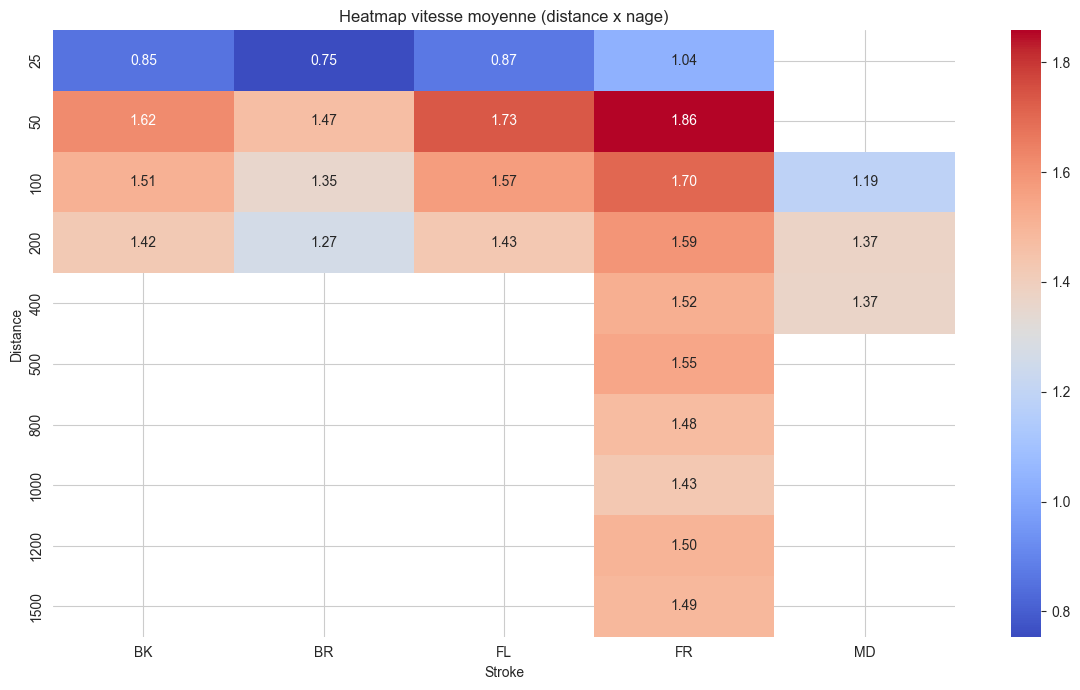

In [74]:
service_graphe = graph_service.ServiceGraphe()

fig = service_graphe.build_figure(graph_service.Graphe5, df)
plt.show()

Max Speed per Split Distance and Stroke:


,Swimmer,Stroke,SplitDistance,SplitSpeed
0,Bazil Gabriel,BK,50,2.452
1,Bastien Thibault,BK,100,2.170
2,Arhab Botko Mathilde,BK,150,2.266
3,Adjesson Aaliyah,BK,200,2.323
4,Tateishi Ryo,BR,50,2.160
5,Karpeeva Svetlana,BR,100,1.937
6,Gyurta Daniel,BR,150,1.620
7,Contrino Gianni,BR,200,2.030
8,Delecluse Theo,FL,50,2.412
9,Soulas Alexis,FL,100,2.285


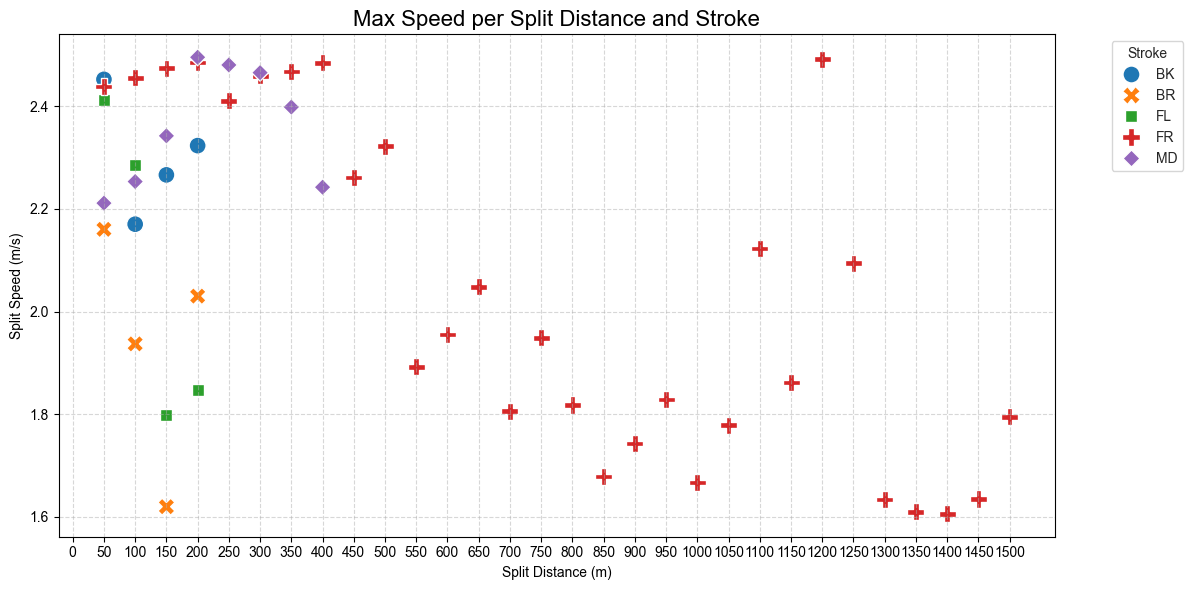

In [16]:
import importlib
import services.graph_service as graph_service_module

importlib.reload(graph_service_module)
service_graphe = graph_service_module.ServiceGraphe()

fig, df_splits_max = service_graphe.build_figure(graph_service_module.Graphe15, df)

if fig is None:
    print("Aucune donnée exploitable pour les vitesses de split.")
else:
    print("Max Speed per Split Distance and Stroke:")
    display(df_splits_max[["Swimmer", "Stroke", "SplitDistance", "SplitSpeed"]])
    plt.show()

,Stroke,SplitDistance,Stat,SpeedValue,N
0,BK,50,Moyenne,1.573572,76360
1,BK,100,Moyenne,1.458406,77327
2,BK,150,Moyenne,1.399020,32227
3,BK,200,Moyenne,1.381839,33650
4,BR,50,Moyenne,1.451056,78097
...,...,...,...,...,...
95,MD,200,Mediane,1.415000,77807
96,MD,250,Mediane,1.237000,28637
97,MD,300,Mediane,1.178000,32956
98,MD,350,Mediane,1.499000,28592


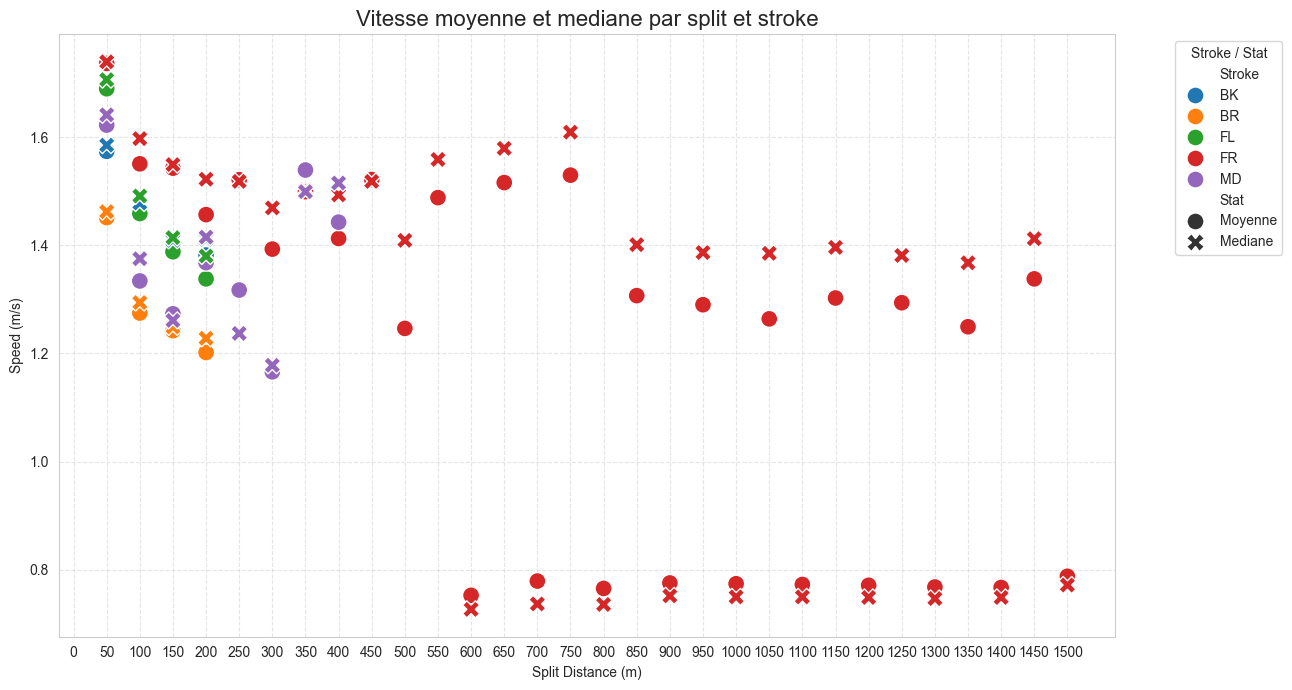

In [80]:
import importlib
import services.graph_service as graph_service_module

importlib.reload(graph_service_module)
service_graphe = graph_service_module.ServiceGraphe()

graphe_vitesse_split = graph_service_module.Graphe16

fig, df_plot = service_graphe.build_figure(graphe_vitesse_split, df=df)

if fig is None:
    print("Aucune donnée exploitable pour ce graphique.")
else:
    display(df_plot[["Stroke", "SplitDistance", "Stat", "SpeedValue", "N"]])
    plt.show()


<h1 style="color:rgb(242, 176, 235); font-size:32px;">Pacing comparatif</h1>

Distance extraite de nom_event : 500
Nombre de performances avec splits valides et dernier split_distance == distance event : 62


,Stroke,SplitDistance,Stat,SpeedValue,N
0,FR,50,Moyenne,1.745339,62
1,FR,100,Moyenne,1.716871,62
2,FR,150,Moyenne,1.672645,62
3,FR,200,Moyenne,1.637274,62
4,FR,250,Moyenne,1.615194,62
5,FR,300,Moyenne,1.625823,62
6,FR,350,Moyenne,1.638290,62
7,FR,400,Moyenne,1.650419,62
8,FR,450,Moyenne,1.677887,62
9,FR,500,Moyenne,1.741581,62


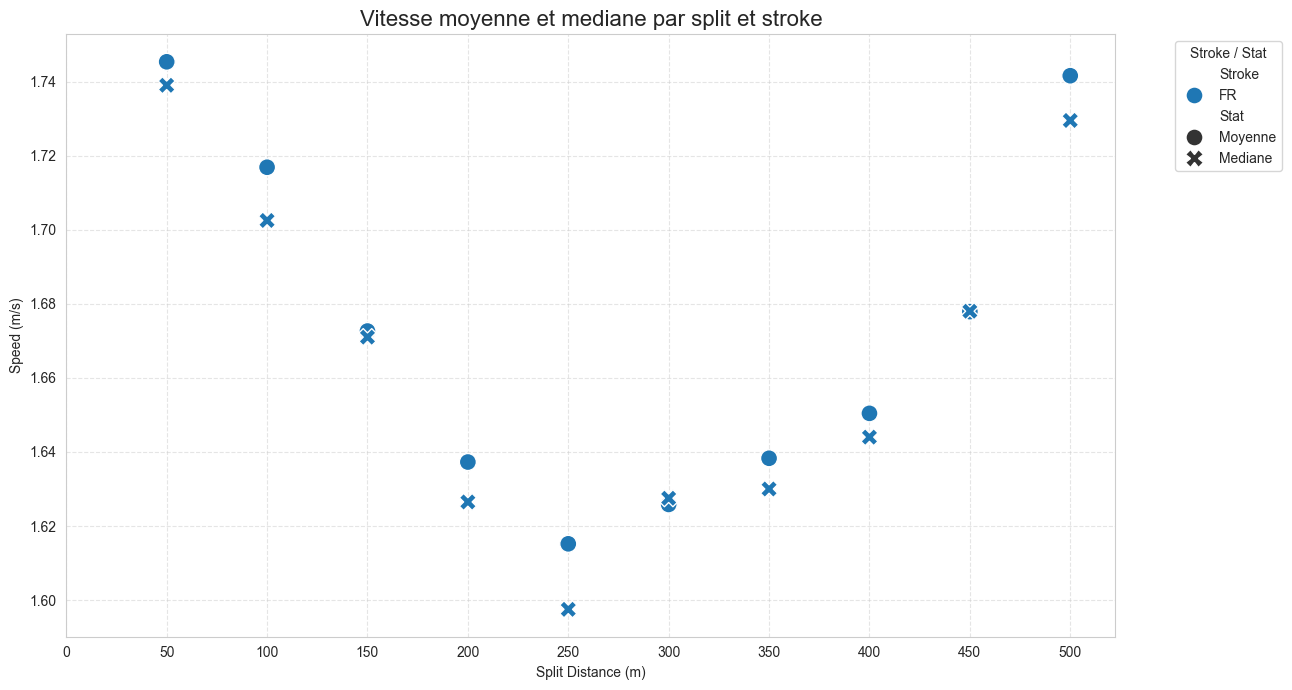

In [19]:
import importlib
import services.graph_service as graph_service_module

importlib.reload(graph_service_module)
service_graphe = graph_service_module.ServiceGraphe()

nom_event = "500 FR LCM"
event_distance, df_splits_event = service_graphe.filter_performances_with_valid_splits_for_event(
    df=df,
    nom_event=nom_event,
)

print("Distance extraite de nom_event :", event_distance)
print("Nombre de performances avec splits valides et dernier split_distance == distance event :", len(df_splits_event))

fig, df_plot = service_graphe.plot_vitesse_moyenne_mediane_par_split_et_nage(df=df_splits_event)
if fig is None:
    print("Aucun graphe disponible : splits insuffisants pour cet event.")
else:
    display(df_plot[["Stroke", "SplitDistance", "Stat", "SpeedValue", "N"]])
    plt.show()

<h2 style="color:gray; font-size:20px;">Split Speed Analysis by Gender with Target Swimmers Comparison</h2>

Distance de l'event : 400
Filtre dernier split appliqué : True
Nombre de performances retenues : 24065


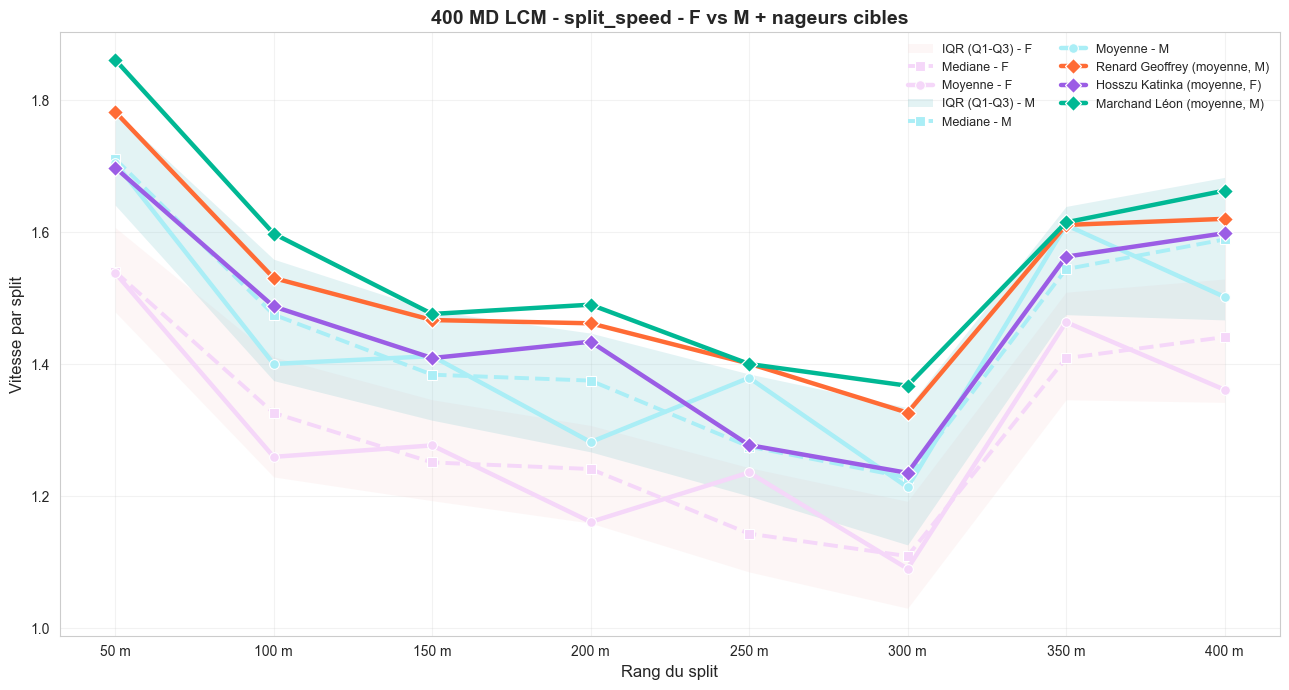

,Gender,split_no,split_distance_theorique,mean,median,q1,q3,n
0,F,1,50,1.5382,1.540,1.479,1.607,9722
1,F,2,100,1.2594,1.326,1.229,1.411,11317
2,F,3,150,1.2768,1.251,1.193,1.346,9503
3,F,4,200,1.1607,1.241,1.159,1.307,11314
4,F,5,250,1.2358,1.143,1.085,1.243,9523
5,F,6,300,1.0898,1.109,1.030,1.192,11313
6,F,7,350,1.4637,1.409,1.346,1.509,9504
7,F,8,400,1.3612,1.441,1.342,1.529,11320
8,M,1,50,1.7052,1.711,1.641,1.783,11032
9,M,2,100,1.4003,1.475,1.375,1.559,12740


,Name,Gender,split_no,split_distance_theorique,target_mean,target_n
0,Hosszu Katinka,F,1,50,1.6979,57
1,Hosszu Katinka,F,2,100,1.4874,58
2,Hosszu Katinka,F,3,150,1.4092,58
3,Hosszu Katinka,F,4,200,1.4340,58
4,Hosszu Katinka,F,5,250,1.2773,57
5,Hosszu Katinka,F,6,300,1.2351,58
6,Hosszu Katinka,F,7,350,1.5629,58
7,Hosszu Katinka,F,8,400,1.5984,58
8,Marchand Léon,M,1,50,1.8613,36
9,Marchand Léon,M,2,100,1.5978,37


Nombre total de valeurs split_speed : 177712


In [81]:
import importlib
import services.graph_service as graph_service_module

importlib.reload(graph_service_module)
service_graphe = graph_service_module.ServiceGraphe()

graphe_split_targets = graph_service_module.Graphe17

nom_event = "400 MD LCM"
swimmer_targets = ["Renard Geoffrey", "Hosszu Katinka", "Marchand Léon"]
target_colors = {
    "Renard Geoffrey": "#FF6B35",
    "Hosszu Katinka": "#9B5DE5",
    "Marchand Léon": "#00B894",
}

fig, stats, target_stats, meta = service_graphe.build_figure(
    graphe_split_targets,
    df=df,
    nom_event=nom_event,
    swimmer_targets=swimmer_targets,
    target_colors=target_colors,
)

print("Distance de l'event :", meta["event_distance"])
print("Filtre dernier split appliqué :", meta["applied_last_filter"])
print("Nombre de performances retenues :", meta["performances_count"])

if fig is None:
    print("Aucune donnée exploitable après nettoyage des splits.")
else:
    plt.show()

    stats_display = stats.copy()
    for col in ["mean", "median", "q1", "q3"]:
        stats_display[col] = stats_display[col].round(4)

    display(
        stats_display[
            ["Gender", "split_no", "split_distance_theorique", "mean", "median", "q1", "q3", "n"]
        ]
    )

    if not target_stats.empty:
        target_display = target_stats.copy()
        target_display["target_mean"] = target_display["target_mean"].round(4)
        display(
            target_display[
                ["Name", "Gender", "split_no", "split_distance_theorique", "target_mean", "target_n"]
            ].sort_values(["Name", "split_no"])
        )

    print("Nombre total de valeurs split_speed :", meta["split_values_count"])


<h1 style="color:rgb(242, 176, 235); font-size:32px;">Petites vérifications</p>

<h2 style="color:gray; font-size:20px;">Vitesse max pour un split avec le meet correspondant</h2>

In [13]:
df_md = df[df["Stroke"].astype("string").str.strip().eq("FR")].copy()

df_md = df_md.explode("splits")
df_md = df_md[df_md["splits"].apply(lambda x: isinstance(x, dict))].copy()

df_md["split_distance"] = df_md["splits"].apply(lambda x: str(x.get("split_distance", "")).strip())
df_md["split_speed"] = pd.to_numeric(
    df_md["splits"].apply(lambda x: x.get("split_speed")),
    errors="coerce"
)

df_150 = df_md[df_md["split_distance"].eq("1400 m") & df_md["split_speed"].notna()].copy()

if df_150.empty:
    print("Aucune valeur de split_speed trouvée pour Stroke='MD' au split_distance='1400 m'.")
else:
    idx = df_150["split_speed"].idxmax()
    row_max = df_150.loc[idx]

    print(f"split_speed max (MD, 150 m) : {row_max['split_speed']}")
    print(f"Meet correspondant           : {row_max['Meet']}")

split_speed max (MD, 150 m) : 1.606
Meet correspondant           : Championnats d'Europe Juniors


<h1 style="color:rgb(242, 176, 235); font-size:32px;">Évolution de la vitesse par splits</h1>

<h2 style="color:gray; font-size:20px;">Lineplot of Speed ​​per split for a precise Swimmer and Event</h2>

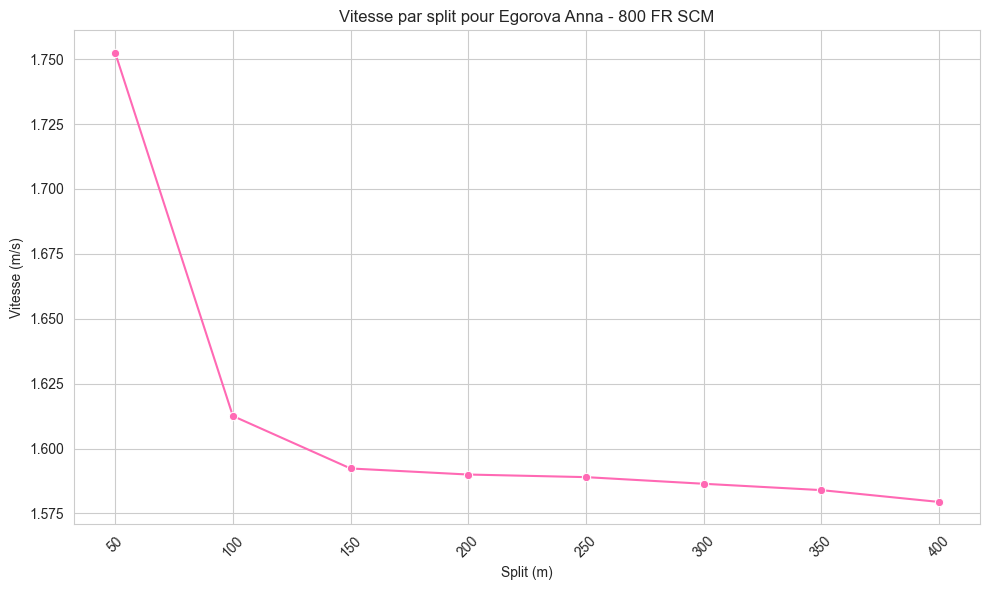

In [84]:
import importlib
import services.graph_service as graph_service_module

importlib.reload(graph_service_module)
service_graphe = graph_service_module.ServiceGraphe()

nom_nageur = "Egorova Anna"
nom_event = "800 FR SCM"

fig, df_splits, gender_nageur = service_graphe.plot_vitesse_par_split_pour_nageur_event(
    df=df,
    nom_nageur=nom_nageur,
    nom_event=nom_event,
)

<h2 style="color:gray; font-size:20px;">Lineplot of split speed for the best swimmers for a specific event (women vs men)</h2>

In [15]:
import pandas as pd

nom_event = "400 MD LCM"
annee_debut = 2022
annee_fin = 2026

df_work = df.copy()

# Nettoyage des noms de colonnes (espaces)
df_work.columns = df_work.columns.map(lambda x: str(x).strip())

# --- Trouver les colonnes indispensables (robuste) ---
event_col = next((c for c in df_work.columns if c.lower() == "event"), None)
swimtime_col = next((c for c in df_work.columns if c.lower() == "swimtimeseconds"), None)
swimmer_col = next((c for c in df_work.columns if c.lower() == "swimmer"), None)

if event_col is None:
    raise ValueError(f"Colonne 'Event' introuvable. Colonnes dispo: {df_work.columns.tolist()}")
if swimtime_col is None:
    raise ValueError(f"Colonne 'SwimTimeSeconds' introuvable. Colonnes dispo: {df_work.columns.tolist()}")
if swimmer_col is None:
    raise ValueError(f"Colonne 'swimmer' introuvable. Colonnes dispo: {df_work.columns.tolist()}")

# --- 1) Créer la colonne 'year' à partir de la meilleure colonne possible ---
# Priorité: une colonne contenant "year" dans son nom (ex: SwimYear)
year_candidates = [c for c in df_work.columns if "year" in c.lower()]
# fallback: sinon une colonne contenant "date" dans son nom (ex: SwimDate, mpp_date)
date_candidates = [c for c in df_work.columns if "date" in c.lower()]

chosen_year_col = None
for pref in ["swimyear", "year", "meetyear", "competitionyear"]:
    cand = next((c for c in year_candidates if c.lower() == pref), None)
    if cand is not None:
        chosen_year_col = cand
        break
if chosen_year_col is None and len(year_candidates) > 0:
    chosen_year_col = year_candidates[0]

if chosen_year_col is not None:
    df_work["year"] = pd.to_numeric(df_work[chosen_year_col], errors="coerce")
else:
    chosen_date_col = None
    for pref in ["swimdate", "date", "mpp_date", "meetdate", "competitiondate"]:
        cand = next((c for c in date_candidates if c.lower() == pref), None)
        if cand is not None:
            chosen_date_col = cand
            break
    if chosen_date_col is None and len(date_candidates) > 0:
        chosen_date_col = date_candidates[0]

    if chosen_date_col is None:
        raise ValueError(
            "Aucune colonne pour l'annee trouvée (Year/Date/variantes). "
            f"Colonnes dispo: {df_work.columns.tolist()}"
        )

    df_work["year"] = pd.to_datetime(df_work[chosen_date_col], errors="coerce").dt.year

# --- 2) Filtrer l'événement ---
df_event = df_work[
    (df_work[event_col] == nom_event) &
    (df_work[swimtime_col].notna()) &
    (df_work[swimmer_col].apply(lambda x: isinstance(x, list) and len(x) == 1)) &
    (df_work["year"].between(annee_debut, annee_fin))
].copy()

if df_event.empty:
    print(f"Aucune performance pour {nom_event} entre {annee_debut} et {annee_fin}.")
else:
    # Extraire infos swimmer depuis la structure swimmer=[{...}]
    def get_field(sw, field):
        if isinstance(sw, list) and len(sw) == 1 and isinstance(sw[0], dict):
            return sw[0].get(field)
        return None

    df_event["swimmer_name"] = df_event[swimmer_col].apply(lambda x: get_field(x, "Name"))
    df_event["swimmer_gender"] = df_event[swimmer_col].apply(lambda x: get_field(x, "Gender"))

    best_row = df_event.nsmallest(1, swimtime_col).iloc[0]

    best_name = best_row["swimmer_name"]
    best_gender = best_row["swimmer_gender"]
    best_time = best_row[swimtime_col]
    best_year = best_row["year"]

    # meet si dispo
    meet_col = next((c for c in df_event.columns if c.lower() == "meet"), None)
    best_meet = best_row[meet_col] if meet_col is not None else "Meet non disponible"

    print(f"Best swimmer ({annee_debut}-{annee_fin}) - {nom_event}")
    print(f"Nageur : {best_name} ({best_gender})")
    print(f"Temps  : {best_time:.2f} sec")
    print(f"Annee  : {int(best_year) if pd.notna(best_year) else 'N/A'}")
    print(f"Meet   : {best_meet}")

Best swimmer (2022-2026) - 400 MD LCM
Nageur : Marchand Léon (M)
Temps  : 242.50 sec
Annee  : 2023
Meet   : Championnats du Monde en grand bassin


Best swimmer (2022-2026) - 400 MD LCM
Nageur : Marchand Léon (M)
Temps  : 242.50 sec
Annee  : 2023
Meet   : Championnats du Monde en grand bassin


,split_distance,split_speed
0,50,1.940
1,100,1.731
2,150,1.592
3,200,1.635
4,250,1.476
5,300,1.481
6,350,1.676
7,400,1.761


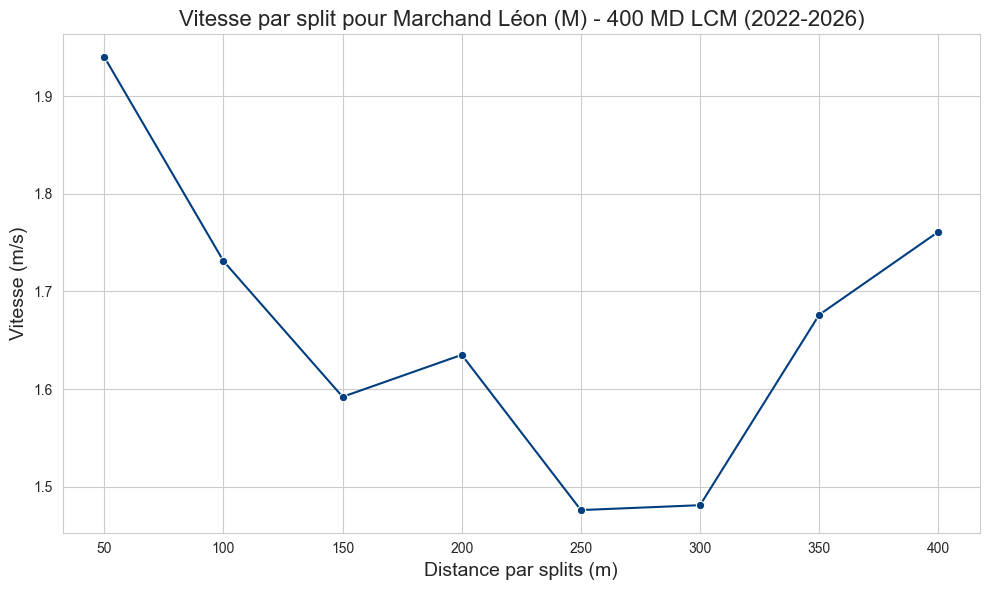

In [85]:
import importlib
import services.graph_service as graph_service_module

importlib.reload(graph_service_module)
service_graphe = graph_service_module.ServiceGraphe()

nom_event = "400 MD LCM"
annee_debut = 2022
annee_fin = 2026

fig, df_splits, meta = service_graphe.build_figure(
    spec=graph_service_module.Graphe19,
    df=df,
    nom_event=nom_event,
    annee_debut=annee_debut,
    annee_fin=annee_fin,
)

if meta.get("message") != "ok":
    print(meta.get("message"))
else:
    print(f"Best swimmer ({annee_debut}-{annee_fin}) - {nom_event}")
    print(f"Nageur : {meta['best_name']} ({meta['best_gender']})")
    print(f"Temps  : {meta['best_time']:.2f} sec")
    best_year = meta.get("best_year")
    print(f"Annee  : {int(best_year) if pd.notna(best_year) else 'N/A'}")
    print(f"Meet   : {meta['best_meet']}")

    display(df_splits)
    plt.show()

<h2 style="color:gray; font-size:20px;">Lineplot of Split Speed Progression of the Best Swimmer in a Given Event (Women vs Men)</h2>

Top men count   : 1
Top women count : 1


,swimmer,gender,split_distance,split_speed,swimmer_label
0,Seto Daiya,M,50,2.009,Seto Daiya (M)
1,Seto Daiya,M,100,1.706,Seto Daiya (M)
2,Seto Daiya,M,150,1.502,Seto Daiya (M)
3,Seto Daiya,M,200,1.745,Seto Daiya (M)
4,Hosszu Katinka,F,50,1.807,Hosszu Katinka (F)
5,Hosszu Katinka,F,100,1.516,Hosszu Katinka (F)
6,Hosszu Katinka,F,150,1.384,Hosszu Katinka (F)
7,Hosszu Katinka,F,200,1.654,Hosszu Katinka (F)


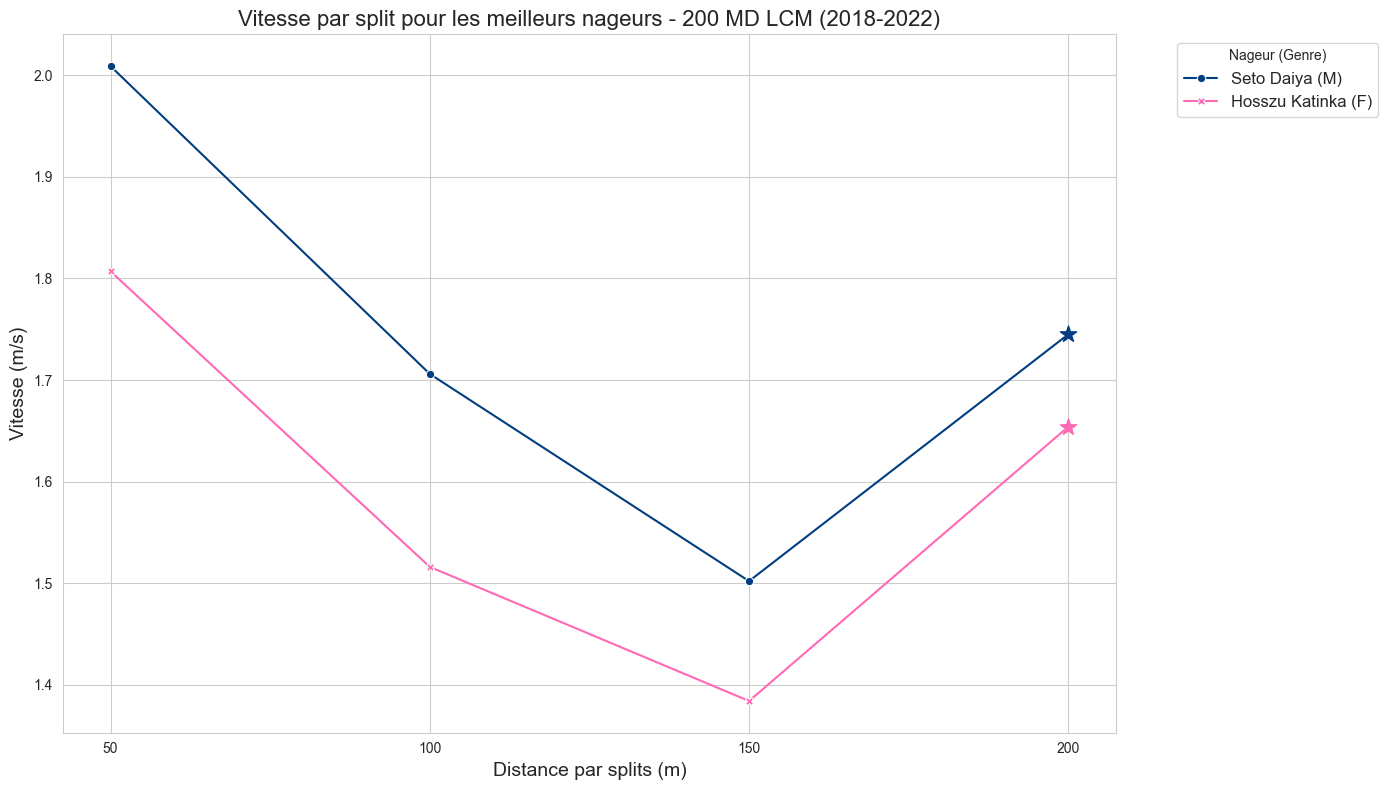

In [86]:
import importlib
import services.graph_service as graph_service_module

importlib.reload(graph_service_module)
service_graphe = graph_service_module.ServiceGraphe()

nom_event = "200 MD LCM"
top_n = 1
annee_debut = 2018
annee_fin = 2022

fig, df_splits, meta = service_graphe.build_figure(
    graph_service_module.Graphe20,
    df,
    nom_event=nom_event,
    annee_debut=annee_debut,
    annee_fin=annee_fin,
    top_n=top_n,
)

if meta.get("message") != "ok":
    print(meta.get("message"))
else:
    print(f"Top men count   : {meta['top_men_count']}")
    print(f"Top women count : {meta['top_women_count']}")
    display(df_splits)
    plt.show()

<h2 style="color:gray; font-size:20px;">Line plot of Split Speed Progression of Top 10 Swimmers in a given Event (Women vs Men)</h2>

,swimmer_name,swimmer_gender,SwimTimeSeconds,year
0,Marchand Léon,M,242.50,2023
1,Foster Carson,M,246.56,2022
2,Kalisz Chase,M,247.47,2022
3,Matsushita Tomoyuki,M,248.32,2025
4,Borodin Ilia,M,249.16,2025
5,Seto Daiya,M,249.41,2023
6,Clareburt Lewis,M,249.72,2024
7,Nishikawa Asaki,M,250.21,2025
8,Smith Brendon,M,250.37,2023
9,Litchfield Max,M,250.40,2024


,swimmer,gender,split_distance,split_speed,swimmer_label
0,Marchand Léon,M,50,1.940,Marchand Léon (M)
1,Marchand Léon,M,100,1.731,Marchand Léon (M)
2,Marchand Léon,M,150,1.592,Marchand Léon (M)
3,Marchand Léon,M,200,1.635,Marchand Léon (M)
4,Marchand Léon,M,250,1.476,Marchand Léon (M)
...,...,...,...,...,...
75,Litchfield Max,M,200,1.599,Litchfield Max (M)
76,Litchfield Max,M,250,1.383,Litchfield Max (M)
77,Litchfield Max,M,300,1.387,Litchfield Max (M)
78,Litchfield Max,M,350,1.687,Litchfield Max (M)


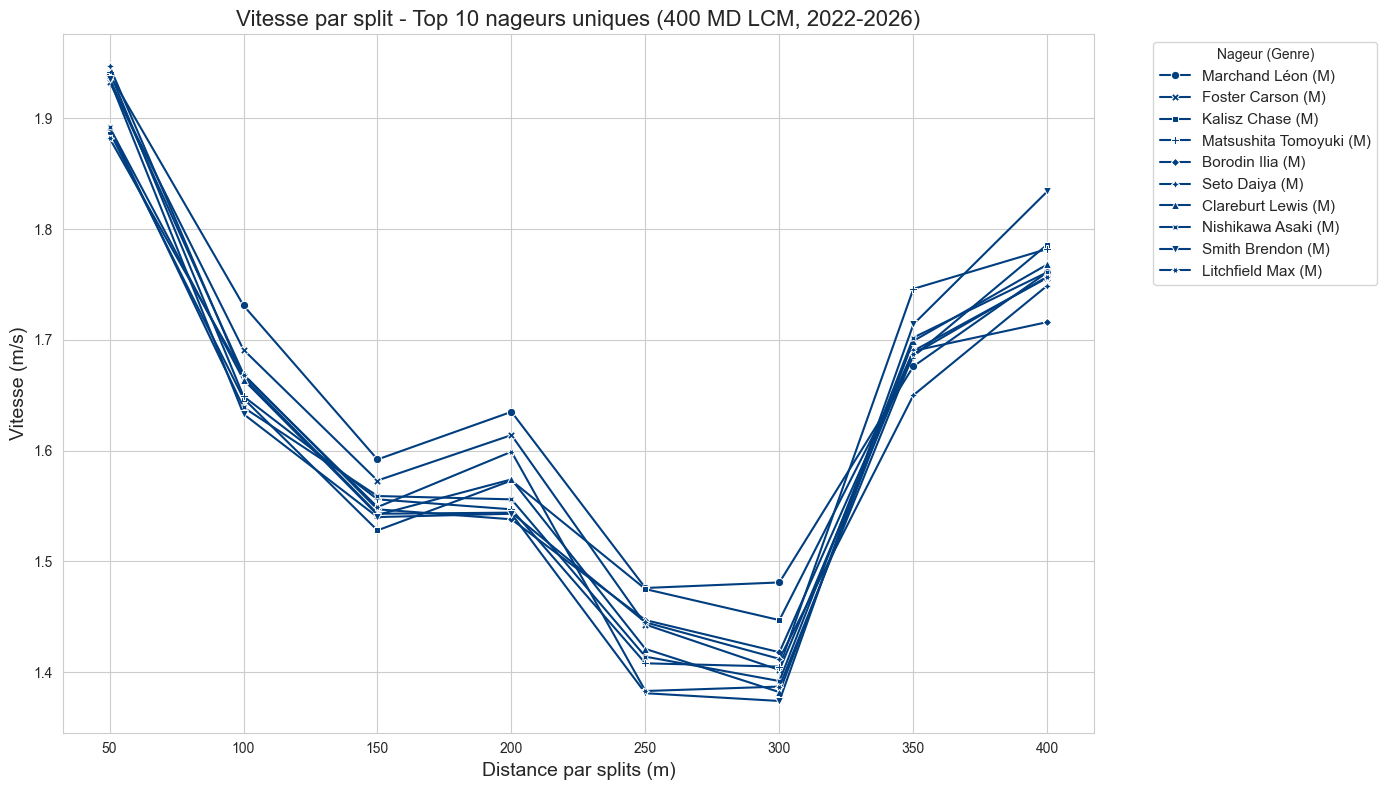

In [87]:
import importlib
import services.graph_service as graph_service_module

importlib.reload(graph_service_module)
service_graphe = graph_service_module.ServiceGraphe()

nom_event = "400 MD LCM"
top_n = 10
annee_debut = 2022
annee_fin = 2026

fig, df_splits, df_top_all, meta = service_graphe.build_figure(
    graph_service_module.Graphe21,
    df,
    nom_event=nom_event,
    annee_debut=annee_debut,
    annee_fin=annee_fin,
    top_n=top_n,
)

if meta.get("message") != "ok":
    print(meta.get("message"))
else:
    display(df_top_all[["swimmer_name", "swimmer_gender", "SwimTimeSeconds", "year"]].reset_index(drop=True))
    display(df_splits)
    plt.show()

<h2 style="color:gray; font-size:20px;">Comparative Heatmap of Swim Speed by Distance and Stroke</h2>

Nombre de lignes du nageur cible : 234


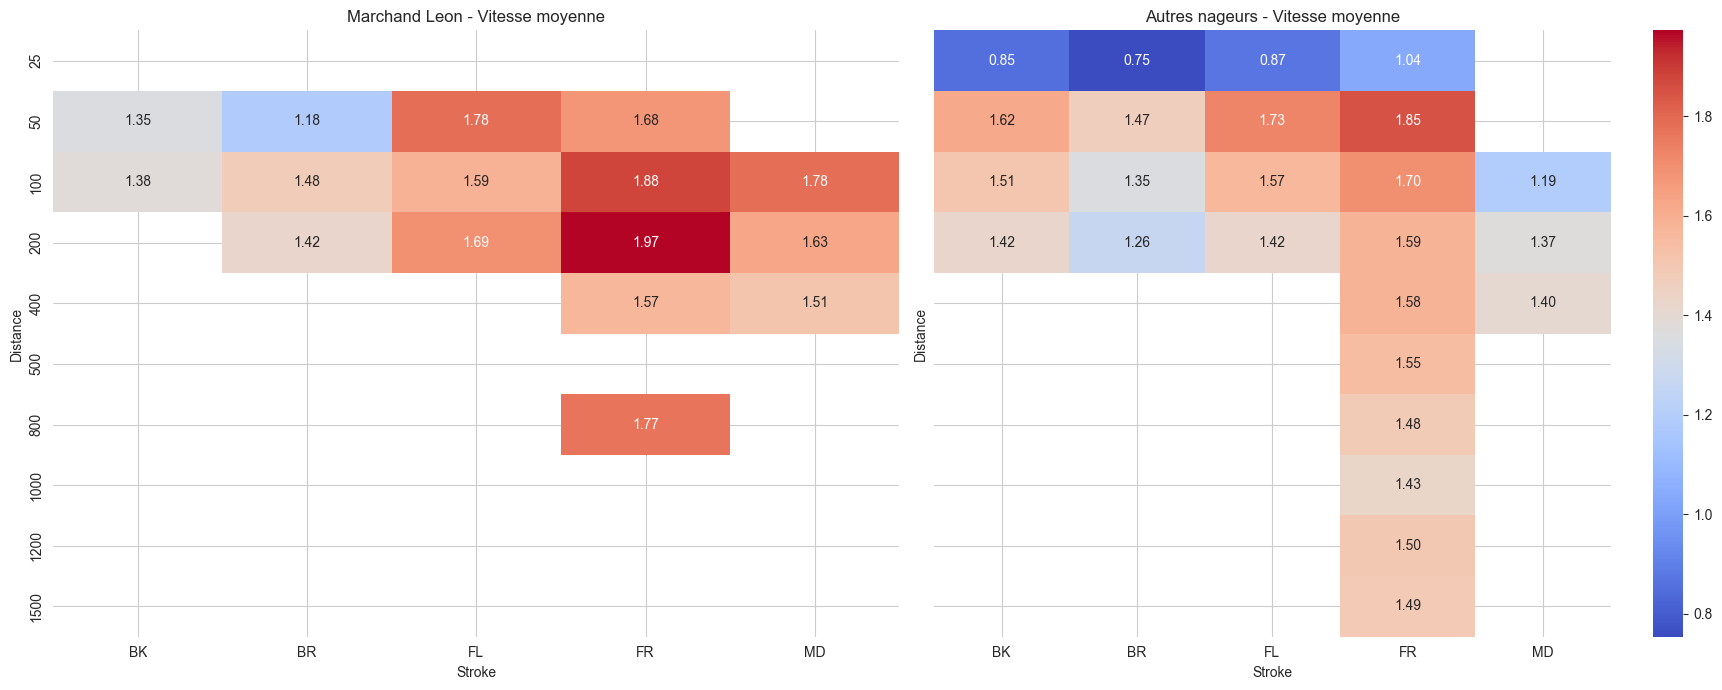

In [88]:
import importlib
import services.graph_service as graph_service_module

importlib.reload(graph_service_module)
service_graphe = graph_service_module.ServiceGraphe()

nageur_cible = "Marchand Leon"
fig, meta = service_graphe.build_figure(
    graph_service_module.Graphe22,
    df,
    nageur_cible=nageur_cible,
)

if meta.get("message") != "ok":
    print(meta.get("message"))
    examples = meta.get("examples")
    if examples is not None:
        print("\nExemples de nageurs disponibles :")
        print(examples)
else:
    print("Nombre de lignes du nageur cible :", meta.get("target_count"))
    plt.show()

<h1 style="color:rgb(242, 176, 235); font-size:32px;">Comparaisons de pacing par splits (à partir de la médiane)</h1>

<h2 style="color:gray; font-size:20px;">Lineplot of median swim time by splits</h2>

Meilleur nageur : Marchand Léon (M)


,split_distance,split_seconds
0,50,30.13
1,100,37.14
2,150,41.72
3,200,33.38


,split_distance,split_seconds
0,50,24.10
1,100,28.40
2,150,32.13
3,200,28.06


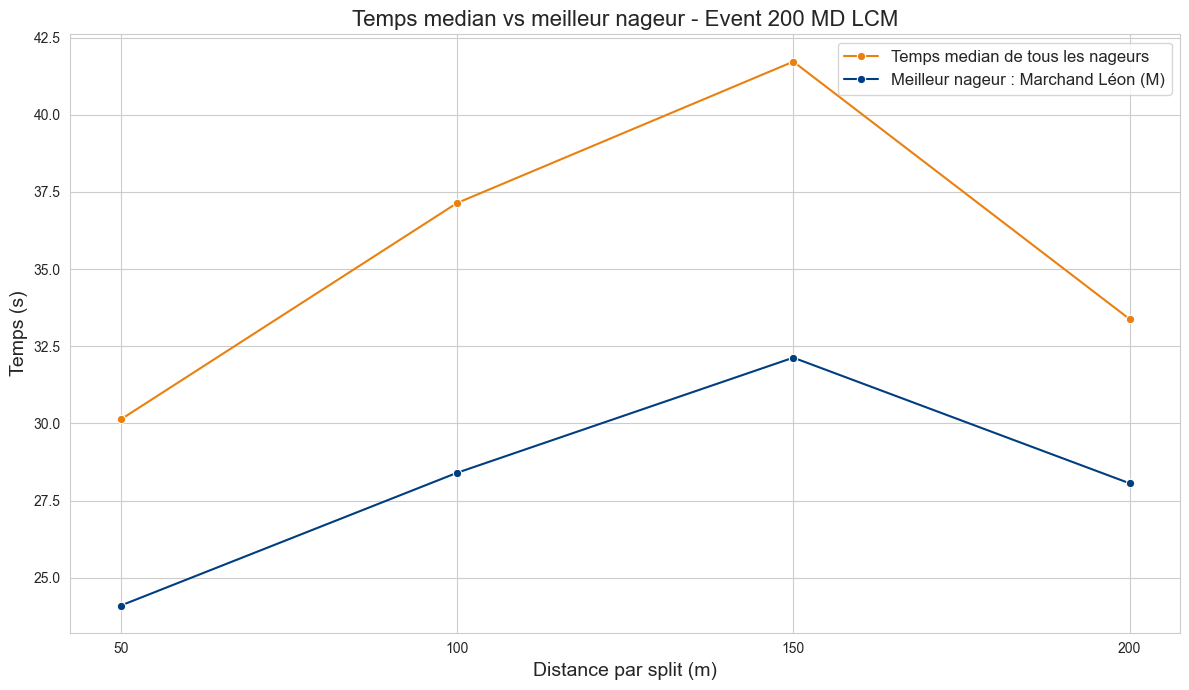

In [89]:
import importlib
import services.graph_service as graph_service_module

importlib.reload(graph_service_module)
service_graphe = graph_service_module.ServiceGraphe()

nom_event = "200 MD LCM"

fig, df_median_splits, df_best_splits, meta = service_graphe.build_figure(
    graph_service_module.Graphe23,
    df,
    nom_event=nom_event,
)

if meta.get("message") != "ok":
    print(meta.get("message"))
else:
    print(f"Meilleur nageur : {meta['best_name']} ({meta['best_gender']})")
    display(df_median_splits)
    display(df_best_splits)
    plt.show()

Top 10 count: 10


,split_distance,split_seconds
0,50,29.67
1,100,34.00
2,150,35.89
3,200,35.29
4,250,39.94
5,300,40.55
6,350,32.90
7,400,31.57


,split_distance,split_seconds
0,50,25.040
1,100,28.835
2,150,30.080
3,200,29.735
4,250,33.375
5,300,33.640
6,350,28.440
7,400,27.240


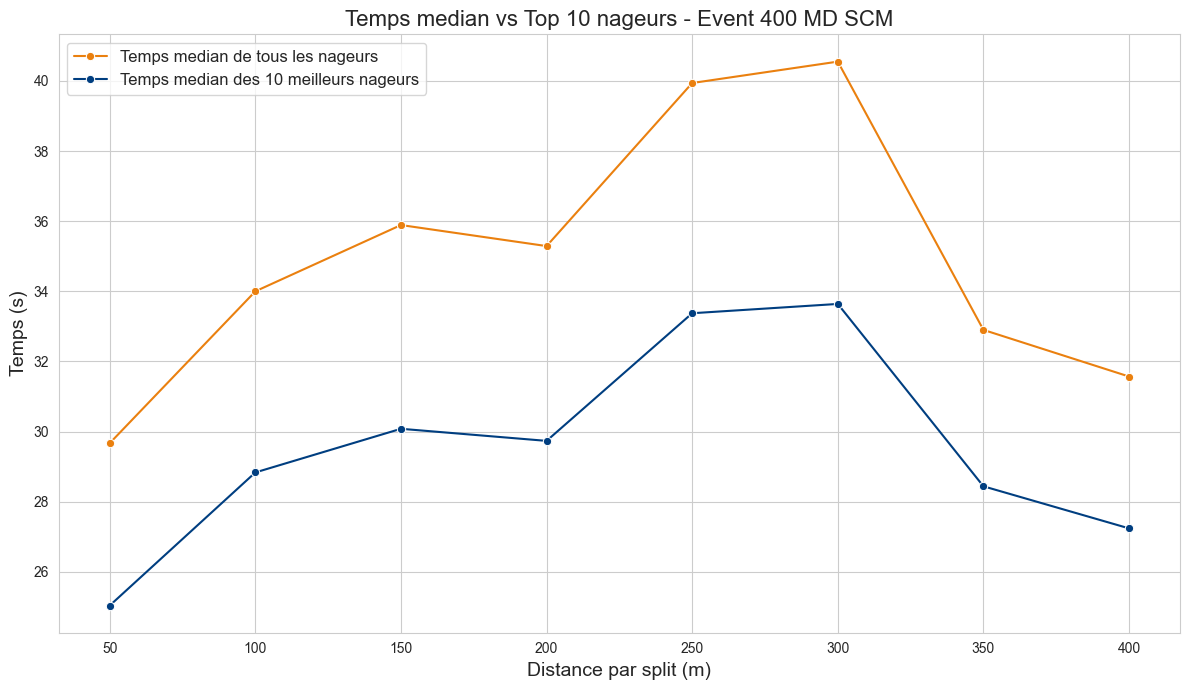

In [90]:
import importlib
import services.graph_service as graph_service_module

importlib.reload(graph_service_module)
service_graphe = graph_service_module.ServiceGraphe()

nom_event = "400 MD SCM"

fig, df_median_splits, df_top10_median, meta = service_graphe.build_figure(
    graph_service_module.Graphe24,
    df,
    nom_event=nom_event,
)

if meta.get("message") != "ok":
    print(meta.get("message"))
else:
    print("Top 10 count:", meta.get("top10_count"))
    display(df_median_splits)
    display(df_top10_median)
    plt.show()

Top men count   : 10
Top women count : 10


,gender,split_distance,split_speed
0,F,50,1.7580
1,F,100,1.5315
2,F,150,1.4605
3,F,200,1.4965
4,F,250,1.2935
5,F,300,1.2680
6,F,350,1.5915
7,F,400,1.6355
8,M,50,1.9505
9,M,100,1.6940


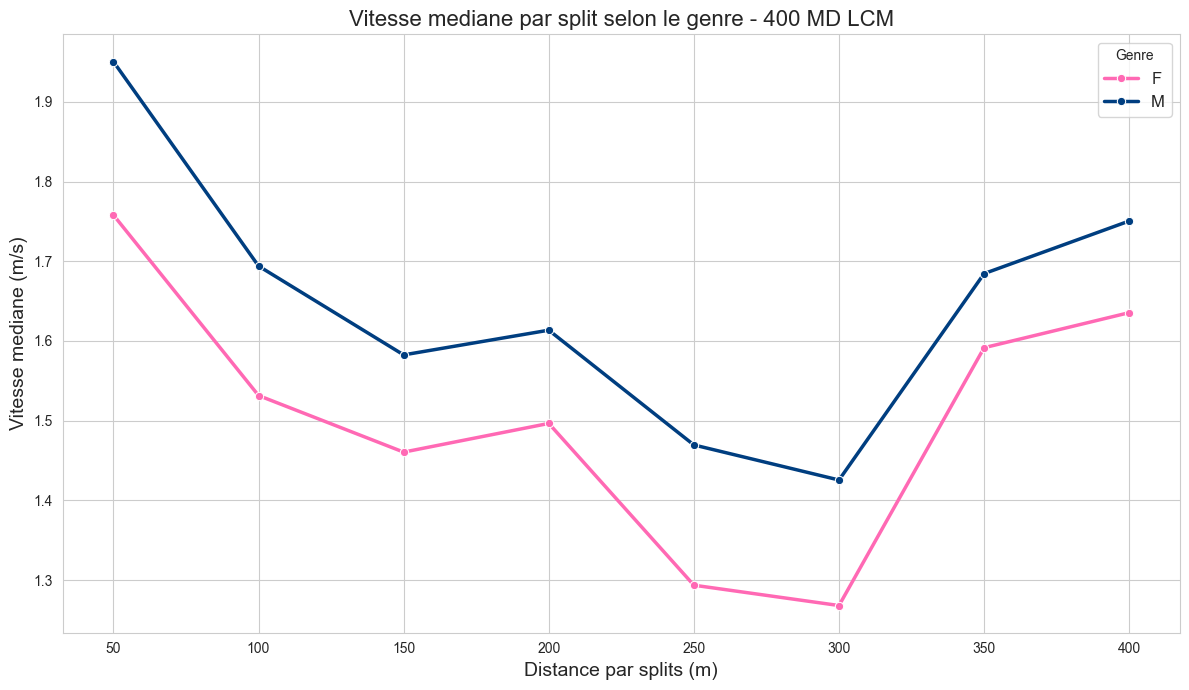

In [91]:
import importlib
import services.graph_service as graph_service_module

importlib.reload(graph_service_module)
service_graphe = graph_service_module.ServiceGraphe()

nom_event = "400 MD LCM"
top_n = 10

fig, df_med, meta = service_graphe.build_figure(
    graph_service_module.Graphe25,
    df,
    nom_event=nom_event,
    top_n=top_n,
)

if meta.get("message") != "ok":
    print(meta.get("message"))
else:
    print(f"Top men count   : {meta['top_men_count']}")
    print(f"Top women count : {meta['top_women_count']}")
    display(df_med)
    plt.show()

<h2 style="color:gray; font-size:20px;">Split 2</h2>

In [121]:
nom_event = "400 MD LCM"
gender_target = "M"

mask = (
    (df["Event"] == nom_event)
    & (df["SwimTimeSeconds"].notna())
    & df["swimmer"].apply(
        lambda x: isinstance(x, list) and len(x) > 0 and x[0].get("Gender") == gender_target
    )
    & df["splits"].apply(lambda x: isinstance(x, list) and len(x) > 0)
    & df["splits"].apply(
        lambda s: str(s[0].get("split_distance")).strip() == "100 m"
        if isinstance(s, list) and len(s) > 0 and isinstance(s[0], dict)
        else False
    )
)

nb_perf_valides = mask.sum()

print(
    f"Nombre de performances valides avec premier split = 100 m pour l'event {nom_event} "
    f"et Gender {gender_target} : {nb_perf_valides}"
)

Nombre de performances valides avec premier split = 100 m pour l'event 400 MD LCM et Gender M : 1713


In [122]:
gender_target = "M"

base_mask = (
    (df["SwimTimeSeconds"].notna())
    & df["swimmer"].apply(
        lambda x: isinstance(x, list) and len(x) > 0 and x[0].get("Gender") == gender_target
    )
    & df["splits"].apply(
        lambda s: isinstance(s, list) and len(s) > 0 and isinstance(s[0], dict)
    )
)

df_base = df.loc[base_mask].copy()
total = len(df_base)

if total == 0:
    print("Aucune performance valide dans la base.")
else:
    first_split = df_base["splits"].apply(lambda s: str(s[0].get("split_distance")).strip())

    n_100 = (first_split == "100 m").sum()
    n_50 = (first_split == "50 m").sum()

    pct_100 = (n_100 / total) * 100
    pct_50 = (n_50 / total) * 100

    print(f"Gender : {gender_target}")
    print(f"Total performances valides (base) : {total}")
    print(f"Premier split = 100 m : {n_100} ({pct_100:.2f}%)")
    print(f"Premier split = 50 m  : {n_50} ({pct_50:.2f}%)")

Gender : M
Total performances valides (base) : 263325
Premier split = 100 m : 10573 (4.02%)
Premier split = 50 m  : 252502 (95.89%)


In [31]:
nom_event = "400 MD LCM"
first_split_target = "400 m"   

mask = (
    (df["Event"] == nom_event)
    & df["splits"].apply(
        lambda s: (
            isinstance(s, list)
            and len(s) > 0
            and isinstance(s[0], dict)
            and str(s[0].get("split_distance")).strip() == first_split_target
        )
    )
)

meets_first_split = (
    df.loc[mask, "Meet"]
      .dropna()
      .astype(str)
      .str.strip()
      .drop_duplicates()
      .sort_values()
      .reset_index(drop=True)
)

print(f"Nombre de meets où le 1er split = {first_split_target} pour {nom_event} : {len(meets_first_split)}")
display(meets_first_split.to_frame(name="Meet"))

df_examples = df.loc[mask, ["Meet", "SwimDate", "Event", "SwimTime", "SwimTimeSeconds", "swimmer", "splits"]].copy()

df_examples["Name"] = df_examples["swimmer"].apply(
    lambda x: x[0].get("Name") if isinstance(x, list) and len(x) > 0 and isinstance(x[0], dict) else None
)
df_examples["Gender"] = df_examples["swimmer"].apply(
    lambda x: x[0].get("Gender") if isinstance(x, list) and len(x) > 0 and isinstance(x[0], dict) else None
)

n_examples = 5

print(f"\nExemple(s) de performances (top {n_examples}) :")
display(
    df_examples[["Meet", "SwimDate", "Name", "Gender", "Event", "SwimTime", "SwimTimeSeconds"]]
    .head(n_examples)
)

if len(df_examples) > 0:
    print("\nSplits détaillés du 1er exemple :")
    display(pd.DataFrame(df_examples.iloc[0]["splits"]))
else:
    print("\nAucune performance trouvée pour ce filtre.")

Nombre de meets où le 1er split = 400 m pour 400 MD LCM : 0


,Meet



Exemple(s) de performances (top 5) :


,Meet,SwimDate,Name,Gender,Event,SwimTime,SwimTimeSeconds



Aucune performance trouvée pour ce filtre.


In [33]:
nom_event = "400 MD LCM" 

base_mask = (
    (df["Event"] == nom_event)
    & df["splits"].apply(lambda s: isinstance(s, list) and len(s) > 0 and isinstance(s[0], dict))
)

df_base = df.loc[base_mask].copy()
total = len(df_base)

if total == 0:
    print("Aucune performance avec splits dans la base filtrée.")
else:
    first_split = df_base["splits"].apply(lambda s: str(s[0].get("split_distance")).strip())

    n_100 = (first_split == "100 m").sum()
    n_50 = (first_split == "50 m").sum()

    pct_100 = (n_100 / total) * 100
    pct_50 = (n_50 / total) * 100

    print(f"Event considéré : {nom_event}")
    print(f"Total performances (avec au moins 1 split) : {total}")
    print(f"Premier split = 100 m : {n_100} ({pct_100:.2f}%)")
    print(f"Premier split = 50 m  : {n_50} ({pct_50:.2f}%)")

Event considéré : 400 MD LCM
Total performances (avec au moins 1 split) : 24065
Premier split = 100 m : 3311 (13.76%)
Premier split = 50 m  : 20754 (86.24%)


In [32]:
nom_event = "400 MD LCM"
gender_target = "F"

df_event = df[
    (df["Event"] == nom_event)
    & (df["swimmer"].apply(lambda x: isinstance(x, list) and len(x) > 0 and x[0].get("Gender") == gender_target))
].copy()

split_rows = []
for _, row in df_event.iterrows():
    splits = row.get("splits", [])
    if isinstance(splits, list):
        for s in splits:
            split_distance = s.get("split_distance")
            split_speed = s.get("split_speed")

            if split_distance is None or split_speed is None:
                continue

            try:
                dist = int(str(split_distance).replace(" m", "").strip())   
                speed = float(split_speed)
            except (ValueError, TypeError):
                continue

            split_rows.append({
                "split_distance": dist,
                "split_speed": speed
            })

df_splits = pd.DataFrame(split_rows)

if df_splits.empty:
    print("Aucune donnée de split_speed trouvée pour 400 MD LCM / Gender M.")
else:
    stats_splits = (
        df_splits
        .groupby("split_distance", as_index=False)
        .agg(
            moyenne_split_speed=("split_speed", "mean"),
            mediane_split_speed=("split_speed", "median"),
            n=("split_speed", "count")
        )
        .sort_values("split_distance")
    )

    stats_splits["moyenne_split_speed"] = stats_splits["moyenne_split_speed"].round(4)
    stats_splits["mediane_split_speed"] = stats_splits["mediane_split_speed"].round(4)

    display(stats_splits)

,split_distance,moyenne_split_speed,mediane_split_speed,n
0,50,1.5382,1.540,9722
1,100,1.2594,1.326,11317
2,150,1.2768,1.251,9503
3,200,1.1607,1.241,11314
4,250,1.2358,1.143,9523
5,300,1.0898,1.109,11313
6,350,1.4637,1.409,9504
7,400,1.3612,1.441,11320


In [11]:
mask_swimmer_list = df["swimmer"].apply(lambda x: isinstance(x, list) and len(x) > 0)

if mask_swimmer_list.any():
    row = df.loc[mask_swimmer_list, ["Meet", "swimmer"]].iloc[0]
    print("Meet :", row["Meet"])
    print("Swimmer :", row["swimmer"])
else:
    print("Aucune performance avec swimmer sous forme de liste non vide.")

Meet : Phase finale Coupe de France des Départements
Swimmer : [{'Name': 'Caillere Melvyn', 'Gender': 'M', 'Year_of_birth': 2012, 'Age': 13, 'Nationality': 'FRA'}]


In [10]:
mask_plusieurs_swimmers = df["swimmer"].apply(lambda x: isinstance(x, list) and len(x) > 1)
df_multi = df.loc[mask_plusieurs_swimmers].copy()

def meme_gender(swimmers):
    genders = {
        s.get("Gender")
        for s in swimmers
        if isinstance(s, dict) and s.get("Gender") is not None
    }
    return len(genders) == 1

df_multi["meme_gender"] = df_multi["swimmer"].apply(meme_gender)

nb_multi = len(df_multi)
nb_meme_gender = df_multi["meme_gender"].sum()
nb_gender_mixte = nb_multi - nb_meme_gender

pct_meme_gender = (nb_meme_gender / nb_multi * 100) if nb_multi > 0 else 0
pct_mixte = (nb_gender_mixte / nb_multi * 100) if nb_multi > 0 else 0

print(f"Performances avec plusieurs swimmers : {nb_multi}")
print(f"Avec même Gender : {nb_meme_gender} ({pct_meme_gender:.2f}%)")
print(f"Avec Gender mixte / incohérent : {nb_gender_mixte} ({pct_mixte:.2f}%)")

display(df_multi.loc[~df_multi["meme_gender"], ["Meet", "Event", "SwimTime", "swimmer"]].head(10))

Performances avec plusieurs swimmers : 36681
Avec même Gender : 36681 (100.00%)
Avec Gender mixte / incohérent : 0 (0.00%)


,Meet,Event,SwimTime,swimmer


<h1 style="color:rgb(242, 176, 235); font-size:32px;">Pacing en relais</h1>

<h2 style="color:gray; font-size:20px;">Split Speed vs Distance (Relay Events) with Mean Trend Line</h2>

,perf_idx,split_distance_m,split_speed,nb_swimmers
0,12029,50,1.677,3
1,12029,100,1.543,3
2,12029,150,1.509,3
3,12029,200,1.500,3
4,12029,250,1.489,3
...,...,...,...,...
32459,720496,400,0.818,4
32460,720497,100,0.801,4
32461,720497,200,0.799,4
32462,720497,300,0.782,4


,split_distance_m,split_speed
0,50,1.882417
1,100,1.554879
2,150,1.886199
3,200,1.504932
4,250,1.869481
5,300,1.492965
6,350,1.891449
7,400,1.513074


,split_distance_m,split_speed
0,50,1.8865
1,100,1.7000
2,150,1.8990
3,200,1.6610
4,250,1.8880
5,300,1.6490
6,350,1.9010
7,400,1.6690


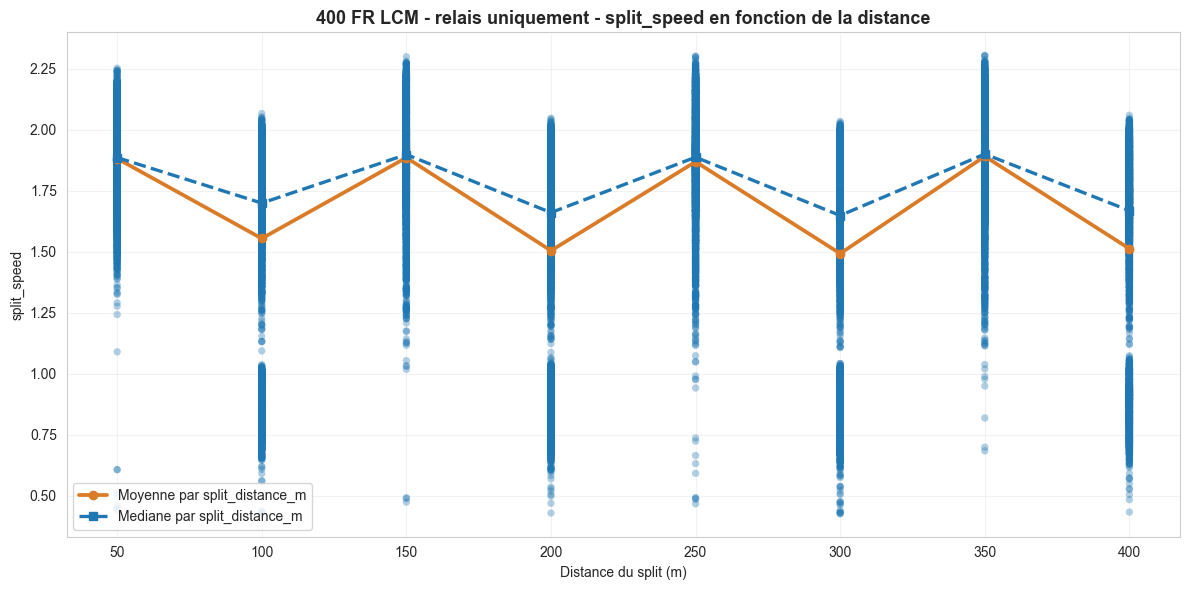

Performances relai retenues : 4679
Points (splits) tracés : 32464


In [92]:
import importlib
import services.graph_service as graph_service_module

importlib.reload(graph_service_module)
service_graphe = graph_service_module.ServiceGraphe()

nom_event = "400 FR LCM"

fig, df_pts, mean_by_dist, median_by_dist, meta = service_graphe.build_figure(
    graph_service_module.Graphe26,
    df,
    nom_event=nom_event,
)

if meta.get("message") != "ok":
    print(meta.get("message"))
else:
    display(df_pts)
    display(mean_by_dist)
    display(median_by_dist)
    plt.show()

print("Performances relai retenues :", meta.get("relay_perf_count", 0))
print("Points (splits) tracés :", meta.get("points_count", 0))

<h1 style="color:rgb(242, 176, 235); font-size:32px;">Couloirs de performance (nageur + événement)</h1>


Genre du nageur : F
Nombre de points nageur : 143


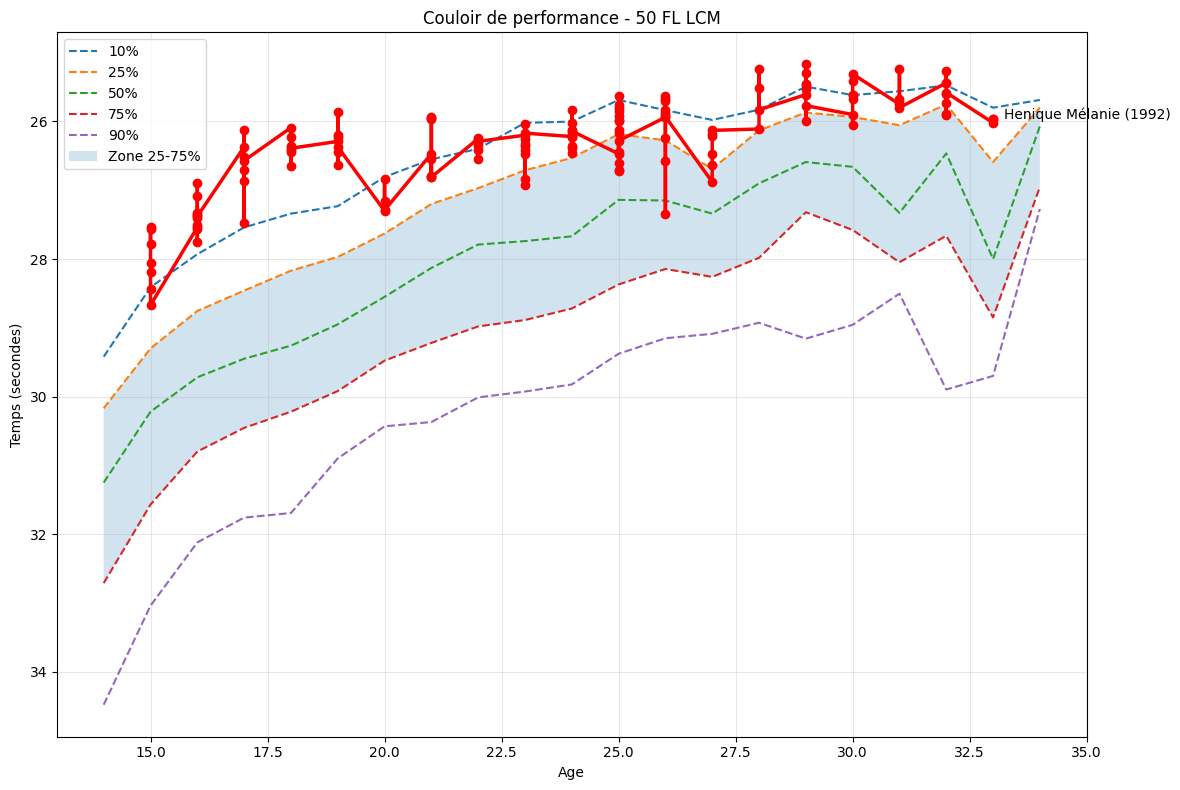

In [ ]:
%matplotlib inline

import importlib
from IPython.display import display
import matplotlib.pyplot as plt

import services.graph_service as graph_service_module

importlib.reload(graph_service_module)
service_graphe = graph_service_module.ServiceGraphe()

nom_event = "50 FL LCM"
nom_nageur = "Henique Mélanie"
year_of_birth = 1992

fig, meta = service_graphe.build_figure(
    graph_service_module.Graphe27,
    df,
    nom_event=nom_event,
    nom_nageur=nom_nageur,
    year_of_birth=year_of_birth,
)

if meta.get("message") != "ok":
    print(meta.get("message"))
    examples = meta.get("examples")
    if examples is not None:
        print("Exemples :", examples)
else:
    print(f"Genre du nageur : {meta.get('gender')}")
    print(f"Nombre de points nageur : {meta.get('points_swimmer')}")
    display(fig)      
    plt.close(fig)    

Genre utilisé : M
Nombre de points : 20041
Ages disponibles : [14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]


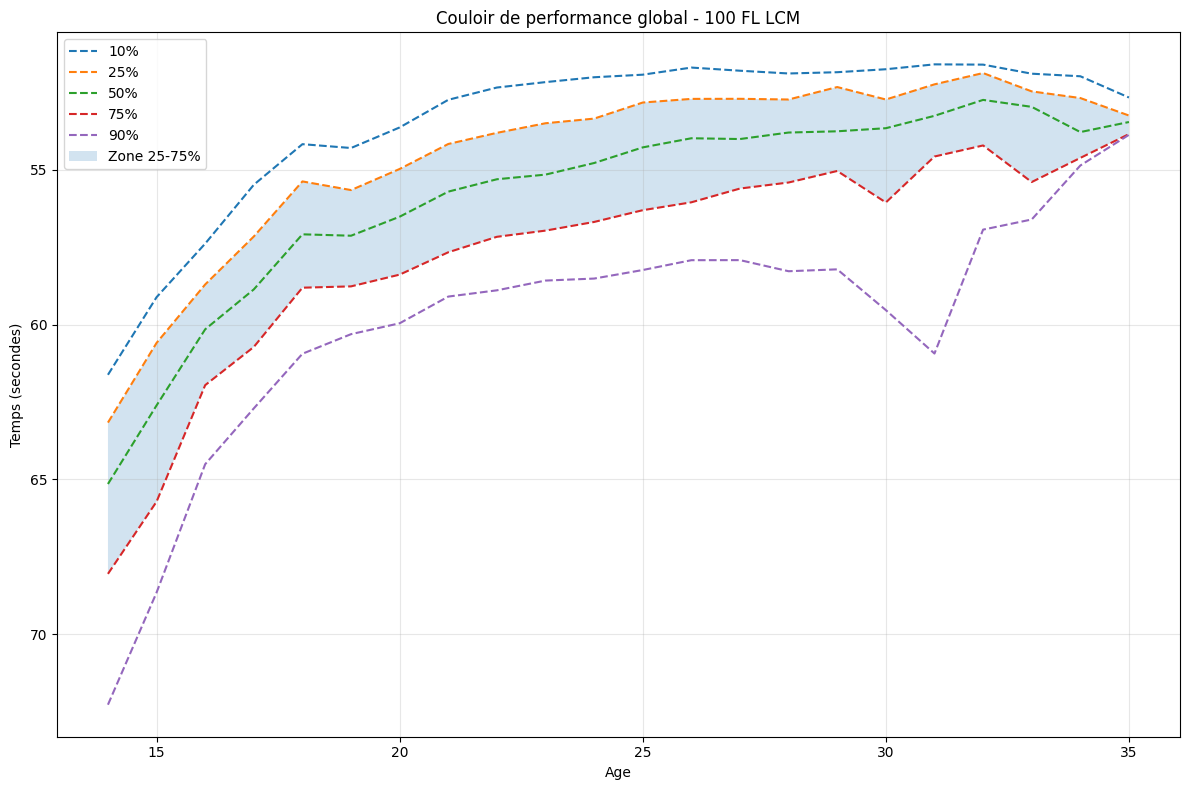

In [ ]:
%matplotlib inline

import importlib
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import services.graph_service as graph_service_module

clear_output(wait=True)
plt.close("all")

importlib.reload(graph_service_module)
service_graphe = graph_service_module.ServiceGraphe()

nom_event = "100 FL LCM"

age_min, age_max = 14, 35
min_points = 5
solo_only = True

fig, meta = service_graphe.build_figure(
    graph_service_module.Graphe28,
    df,
    nom_event=nom_event,
    age_min=age_min,
    age_max=age_max,
    min_points=min_points,
    solo_only=solo_only,
)

if print()
if meta.get("message") != "ok":
    print(meta.get("message"))
else:
    print(f"Genre utilisé : {meta.get('gender')}")
    print(f"Nombre de points : {meta.get('points_count')}")
    print(f"Ages disponibles : {meta.get('ages_available')}")
    display(fig)
    plt.close(fig)

Genre utilisé : F
Ages disponibles : [14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
Nageur tracé : Henique Mélanie (1992)
Nombre de points nageur : 45


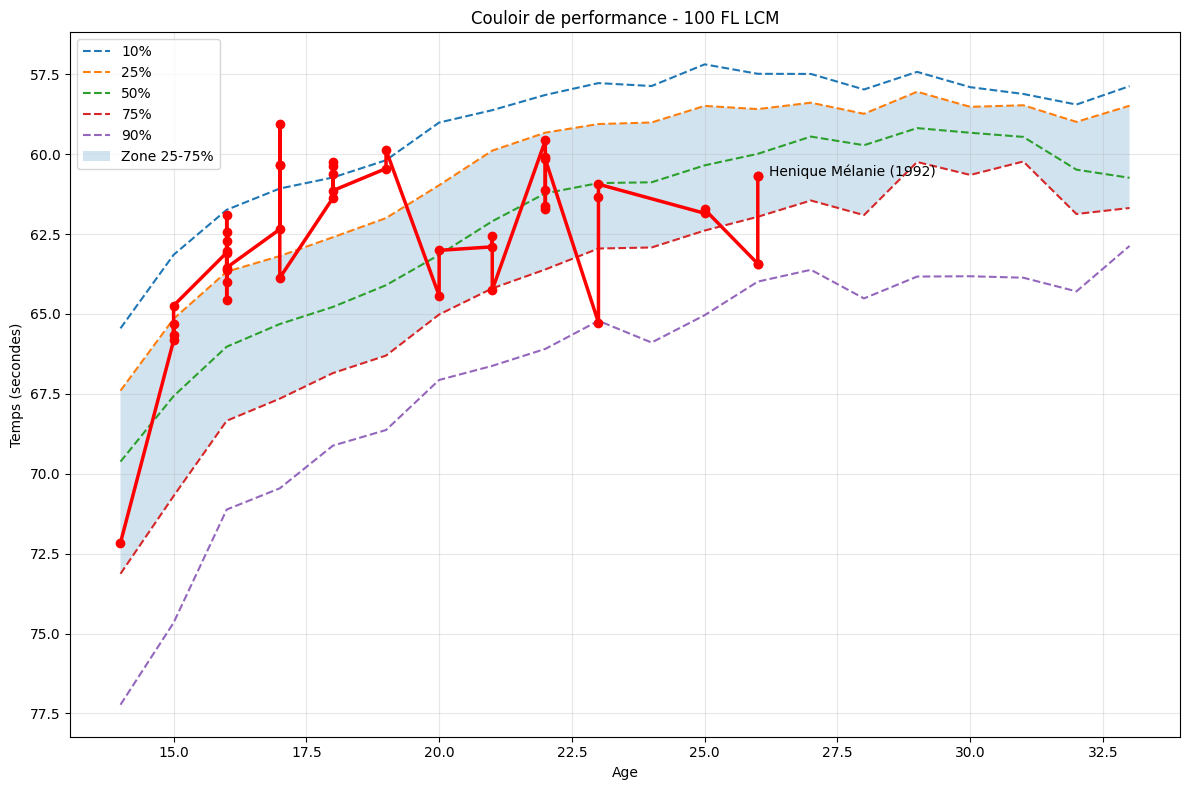

In [5]:
%matplotlib inline

import importlib
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import services.graph_service as graph_service_module

clear_output(wait=True)
plt.close("all")

importlib.reload(graph_service_module)
service_graphe = graph_service_module.ServiceGraphe()

nom_event = "100 FL LCM"
age_min, age_max = 14, 35
min_points = 5
solo_only = True

# Optionnel: mettre None si tu veux le couloir global seul
nom_nageur = "Henique Mélanie"   # ou None
year_of_birth = 1992             # ou None

use_swimmer = bool(nom_nageur) and (year_of_birth is not None)

if use_swimmer:
    # Couloir + nageur cible
    fig, meta = service_graphe.build_figure(
        graph_service_module.GRAPHES_PAR_KEY["performance_corridor_plot_time"],  # Graphe27
        df,
        nom_event=nom_event,
        nom_nageur=nom_nageur,
        year_of_birth=int(year_of_birth),
        age_min=age_min,
        age_max=age_max,
        min_points=min_points,
        solo_only=solo_only,
    )
else:
    # Couloir global seul
    fig, meta = service_graphe.build_figure(
        graph_service_module.GRAPHES_PAR_KEY["performance_corridor_global_plot_time"],  # Graphe28
        df,
        nom_event=nom_event,
        age_min=age_min,
        age_max=age_max,
        min_points=min_points,
        solo_only=solo_only,
    )

if meta.get("message") != "ok":
    print(meta.get("message"))
    examples = meta.get("examples")
    if examples is not None:
        print("Exemples :", examples)
else:
    print(f"Genre utilisé : {meta.get('gender')}")
    print(f"Ages disponibles : {meta.get('ages_available')}")
    if use_swimmer:
        print(f"Nageur tracé : {meta.get('swimmer_name')} ({meta.get('year_of_birth')})")
        print(f"Nombre de points nageur : {meta.get('points_swimmer')}")
    else:
        print(f"Nombre de points : {meta.get('points_count')}")
    display(fig)
    plt.close(fig)

Plage d'âges auto: 2 -> 67
Genre utilisé : F
Ages disponibles : [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
Nageur tracé : Henique Mélanie (1992)
Nombre de points nageur : 45


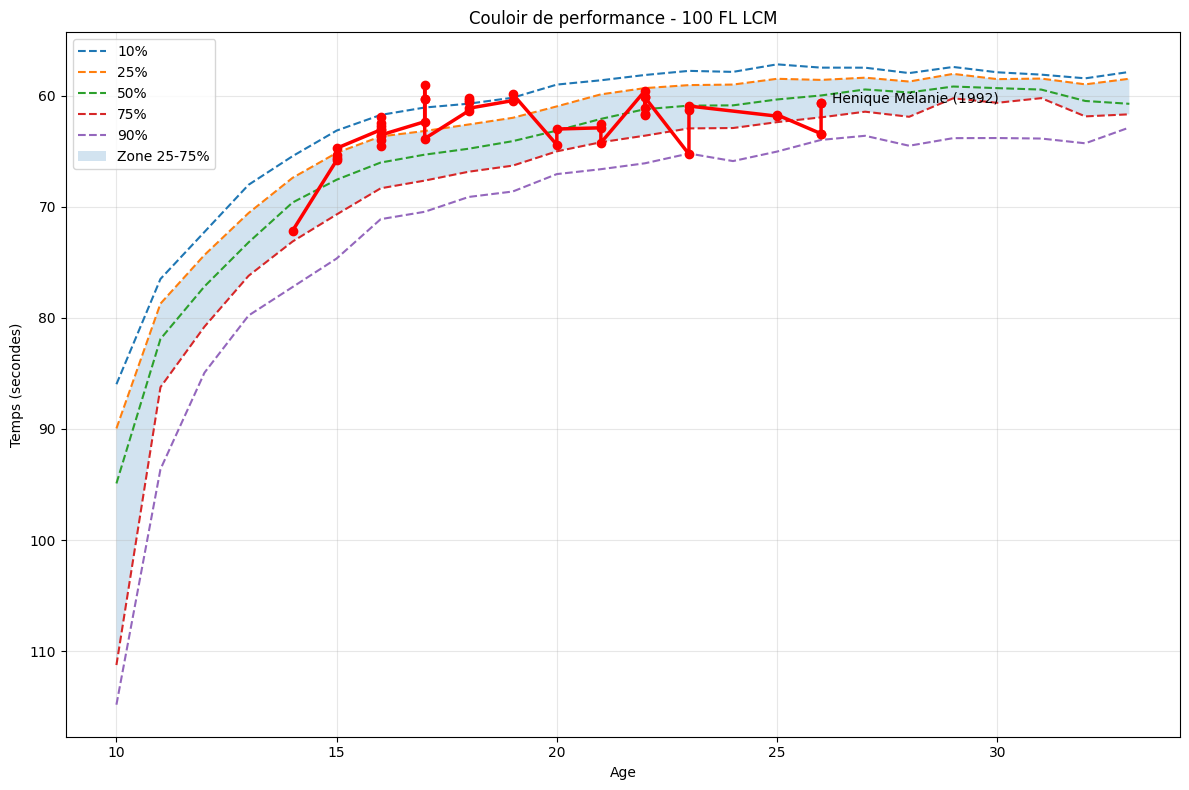

In [ ]:
%matplotlib inline


import importlib
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import pandas as pd
import services.graph_service as graph_service_module

clear_output(wait=True)
plt.close("all")

importlib.reload(graph_service_module)
service_graphe = graph_service_module.ServiceGraphe()

nom_event = "100 FL LCM"
solo_only = True
min_points = 5

# Optionnel: nageur cible (sinon laisse None pour couloir global)
nom_nageur = "Henique Mélanie"   # ou None
year_of_birth = 1992             # ou None
use_swimmer = bool(nom_nageur) and (year_of_birth is not None)

# --- Calcul age_min / age_max sur TOUS les participants de l'event ---
required_cols = ["swimmer", "SwimDate", "Event", "SwimTimeSeconds"]
data = df.loc[:, required_cols]

if solo_only:
    data = data[data["swimmer"].apply(lambda x: isinstance(x, list) and len(x) == 1)].copy()
else:
    data = data.copy()

data["swimmer_dict"] = data["swimmer"].apply(
    lambda x: x[0] if isinstance(x, list) and len(x) == 1 else None
)
data["Year_of_birth"] = data["swimmer_dict"].apply(
    lambda x: x.get("Year_of_birth") if isinstance(x, dict) else None
)
data["Age_json"] = data["swimmer_dict"].apply(
    lambda x: x.get("Age") if isinstance(x, dict) else None
)
data["SwimYear"] = pd.to_datetime(data["SwimDate"], errors="coerce").dt.year
data["Age_swim"] = data["Age_json"]

mask = data["Age_swim"].isna() & data["Year_of_birth"].notna() & data["SwimYear"].notna()
data.loc[mask, "Age_swim"] = data.loc[mask, "SwimYear"] - data.loc[mask, "Year_of_birth"]
data["Age_swim"] = pd.to_numeric(data["Age_swim"], errors="coerce")

ages_event = data.loc[
    (data["Event"] == nom_event) & data["Age_swim"].notna(),
    "Age_swim"
]

if ages_event.empty:
    raise ValueError(f"Aucun âge exploitable pour l'événement {nom_event}")

age_min = int(ages_event.min())
age_max = int(ages_event.max())
print(f"Plage d'âges auto: {age_min} -> {age_max}")

# --- Build figure ---
if use_swimmer:
    spec = graph_service_module.GRAPHES_PAR_KEY["performance_corridor_plot_time"]   # Graphe27
    kwargs = dict(nom_nageur=nom_nageur, year_of_birth=int(year_of_birth))
else:
    spec = graph_service_module.GRAPHES_PAR_KEY["performance_corridor_global_plot_time"]  # Graphe28
    kwargs = {}

fig, meta = service_graphe.build_figure(
    spec,
    df,
    nom_event=nom_event,
    age_min=age_min,
    age_max=age_max,
    min_points=min_points,
    solo_only=solo_only,
    **kwargs,
)

if meta.get("message") != "ok":
    print(meta.get("message"))
    if meta.get("examples") is not None:
        print("Exemples :", meta.get("examples"))
else:
    print(f"Genre utilisé : {meta.get('gender')}")
    print(f"Ages disponibles : {meta.get('ages_available')}")
    if use_swimmer:
        print(f"Nageur tracé : {meta.get('swimmer_name')} ({meta.get('year_of_birth')})")
        print(f"Nombre de points nageur : {meta.get('points_swimmer')}")
    else:
        print(f"Nombre de points : {meta.get('points_count')}")
    display(fig)
    plt.close(fig)